<a href="https://colab.research.google.com/github/Lubna-AlAmri/metabolic-disorder-prediction/blob/main/Metabolic_Disorder_Classification_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metabolic Disorder Classification Analysis
## Patient Dataset: patients_01.csv

**Objective:** Build a predictive model to classify diseased patients (metabolic disorder) from healthy individuals using clinical and lifestyle features.

---

## 1. Setup and Data Loading

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# For reproducibility
np.random.seed(42)

In [5]:
# Set visualization style
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:
# Load the dataset
df = pd.read_csv('patients_01.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]-1}")  # Excluding target
print("\nFirst few rows:")

df.head(10)

Dataset Shape: (5124, 18)
Number of samples: 5124
Number of features: 17

First few rows:


,age,gender,bmi,high_chol,chol_check,history_stroke,history_heart_disease,history_smoking,amount_activity,alcohol_misuse,fruits,vegetables,health_gen,health_ment,health_phys,walking_diff,high_bp,dissease
0,68,female,20,normal,checked,False,False,False,active,2.0,True,True,1.0,0.0,0.0,False,normal,False
1,54,female,47,normal,checked,False,False,True,active,1.0,True,True,3.0,0.0,0.0,False,normal,False
2,55,female,30,normal,checked,False,False,False,active,0.0,True,True,1.0,0.0,0.0,False,high,False
3,44,female,19,normal,notchecked,False,False,NaN,active,6.0,True,True,3.0,20.0,6.0,False,normal,False
4,61,male,32,normal,checked,False,False,False,NaN,NaN,True,NaN,2.0,0.0,0.0,True,normal,False
5,36,female,24,normal,checked,False,False,False,NaN,4.0,NaN,True,1.0,5.0,0.0,False,normal,False
6,55,male,37,high,notchecked,False,False,NaN,NaN,NaN,True,True,2.0,0.0,0.0,False,normal,False
7,44,female,56,high,checked,False,False,False,NaN,1.0,False,False,3.0,0.0,1.0,False,high,True
8,39,female,26,normal,checked,False,False,False,notactive,1.0,True,True,2.0,0.0,0.0,False,normal,False
9,67,male,26,normal,checked,False,False,NaN,active,0.0,False,True,4.0,0.0,0.0,False,high,False


## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Data Properties

The primary purpose of performing exploratory data analysis (EDA) is to summarize the main characteristics of a dataset and to summarize the main characteristics of a dataset. EDA helps in detecting anomalies, spotting patterns, testing hypotheses, and checking assumptions. It lays the foundation for deeper data analysis, ensuring better insights and informed decision-making.

We have 18 features in total

In [54]:
# Data types and basic info
print("\n --- DATA TYPES --- ")
print(df.dtypes)
print("\n --- BASIC INFO --- ")
df.info()


 --- DATA TYPES --- 
age                        int64
gender                    object
bmi                        int64
high_chol                 object
chol_check                object
history_stroke              bool
history_heart_disease     object
history_smoking           object
amount_activity           object
alcohol_misuse           float64
fruits                    object
vegetables                object
health_gen               float64
health_ment              float64
health_phys              float64
walking_diff                bool
high_bp                   object
dissease                    bool
dtype: object

 --- BASIC INFO --- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5124 entries, 0 to 5123
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5124 non-null   int64  
 1   gender                 5124 non-null   object 
 2   bmi                    5124 

In [8]:
# Identify feature types
numerical_features = ['age', 'bmi', 'alcohol_misuse', 'health_gen', 'health_ment', 'health_phys']
categorical_features = ['gender', 'high_chol', 'chol_check', 'history_stroke', 'history_heart_disease',
                       'history_smoking', 'amount_activity', 'fruits', 'vegetables', 'walking_diff', 'high_bp']
target = 'dissease'

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nTarget variable: {target}")

Numerical features (6): ['age', 'bmi', 'alcohol_misuse', 'health_gen', 'health_ment', 'health_phys']

Categorical features (11): ['gender', 'high_chol', 'chol_check', 'history_stroke', 'history_heart_disease', 'history_smoking', 'amount_activity', 'fruits', 'vegetables', 'walking_diff', 'high_bp']

Target variable: dissease


**What are these features telling us ?**

age -	age in years

gender -	 Female or Male

bmi -	 Body Mass Index (BMI)

alcohol_misuse	-  value of number of drinks per week (numerical)

high_bp -	" Adults who have been told they have high blood pressure by a doctor, nurse, or other health professional  (binary)"

high_col -	" Have you EVER been told by a doctor, nurse or other health professional that your blood cholesterol is high?  (binary)"

chol_check -	 Cholesterol check within past five years  (binary)

history_smoking - Have you smoked at least 100 cigarettes in your entire life? [Note	 5 packs = 100 cigarettes]  (binary)

history_stroke 	- (Ever told) you had a stroke. (binary)
history_heart_disease	 Respondents that have ever reported having coronary heart disease (CHD) or myocardial infarction (MI) (binary)

amount_activity - Adults who reported doing physical activity or exercise during the past 30 days other than their regular job (binary)

fruits 	- Consume Fruit 1 or more times per day (binary)

vegetables -	 Consume Vegetables 1 or more times per day  (binary)

health_gen - Would you say that in general your health is	 rate  (numerical score)

health_men -	" Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good?  (numerical score)"

health_phys -	" Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? (numerical score)"

walking_diff -	 Do you have serious difficulty walking or climbing stairs? (binary)


### 2.2 Target Variable Distribution

We want to see if the disease state distribution variabliety is equal or not

-- TARGET VARIABLE DISTRIBUTION --
dissease
False    4188
True      936
Name: count, dtype: int64

Proportions:
dissease
False    0.81733
True     0.18267
Name: proportion, dtype: float64


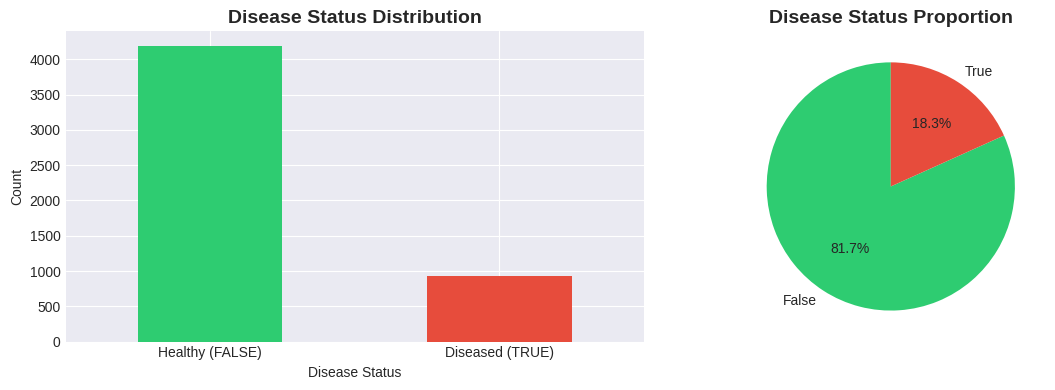


Class imbalance ratio: 0.223
**Warning**: Dataset is imbalanced. Consider using appropriate metrics and techniques.


In [57]:
# Target variable distribution
print("-- TARGET VARIABLE DISTRIBUTION --")
print(df[target].value_counts())
print("\nProportions:")
print(df[target].value_counts(normalize=True))

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df[target].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Disease Status Distribution', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Disease Status')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['Healthy (FALSE)', 'Diseased (TRUE)'], rotation=0)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
df[target].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                colors=colors, startangle=90)
ax[1].set_title('Disease Status Proportion', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Check for class imbalance
imbalance_ratio = df[target].value_counts().min() / df[target].value_counts().max()
print(f"\nClass imbalance ratio: {imbalance_ratio:.3f}")
if imbalance_ratio < 0.5:
    print("**Warning**: Dataset is imbalanced. Consider using appropriate metrics and techniques.")

### 2.3 Missing Data Analysis

-- MISSING DATA SUMMARY --
                       Missing_Count  Missing_Percentage
history_smoking                 1514           29.547229
alcohol_misuse                  1026           20.023419
amount_activity                  933           18.208431
high_chol                        336            6.557377
chol_check                       286            5.581577
health_phys                      151            2.946916
vegetables                       112            2.185792
fruits                           105            2.049180
health_ment                       83            1.619828
health_gen                        60            1.170960
history_heart_disease             52            1.014832


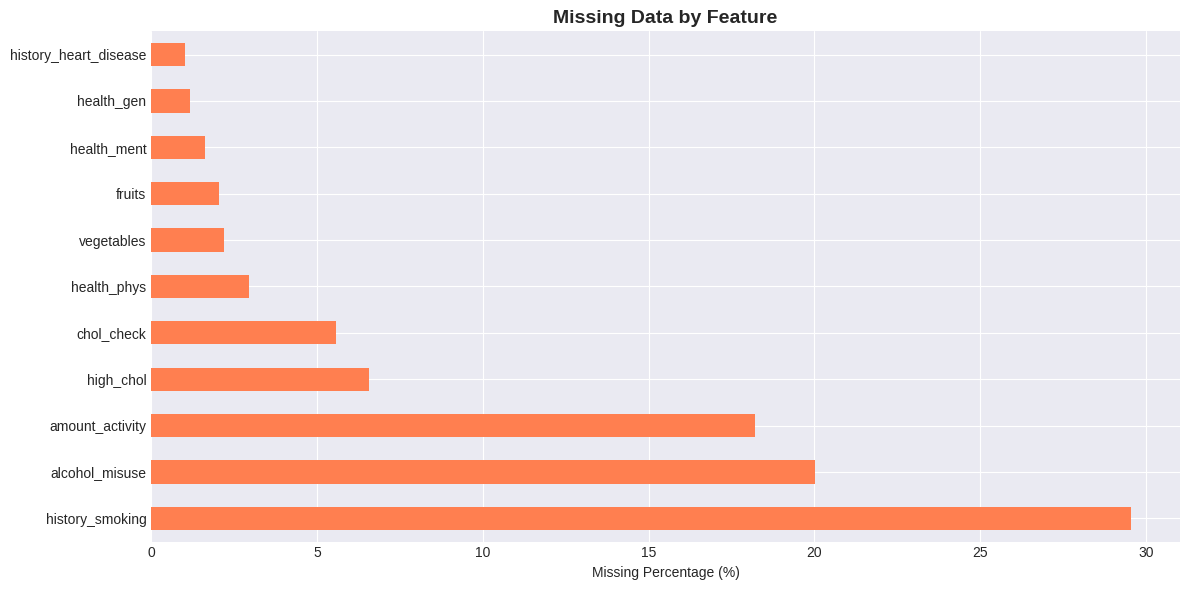

In [59]:
# Missing data summary
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print("-- MISSING DATA SUMMARY --")
if len(missing_data) > 0:
    print(missing_data)

    # Visualize missing data
    plt.figure(figsize=(12, 6))
    missing_data['Missing_Percentage'].plot(kind='barh', color='coral')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Data by Feature', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No missing data found!")

Results show that smoking has the highest missing percentage of data followed by alcohol misuse.

### 2.4 Numerical Features Analysis

In [60]:
# Descriptive statistics for numerical features
print("--- NUMERICAL FEATURES STATISTICS ---")
df[numerical_features].describe().T

--- NUMERICAL FEATURES STATISTICS ---


,count,mean,std,min,25%,50%,75%,max
age,5124.0,55.038642,16.497927,16.0,43.0,56.0,66.0,104.0
bmi,5124.0,28.123341,6.919013,0.0,24.0,27.0,31.0,87.0
alcohol_misuse,4098.0,2.394339,2.908278,0.0,1.0,2.0,3.0,27.0
health_gen,5064.0,2.468009,1.089227,0.0,2.0,2.0,3.0,5.0
health_ment,5041.0,3.399127,7.732750,0.0,0.0,0.0,2.0,30.0
health_phys,4973.0,4.007641,9.619864,0.0,0.0,0.0,2.0,87.0


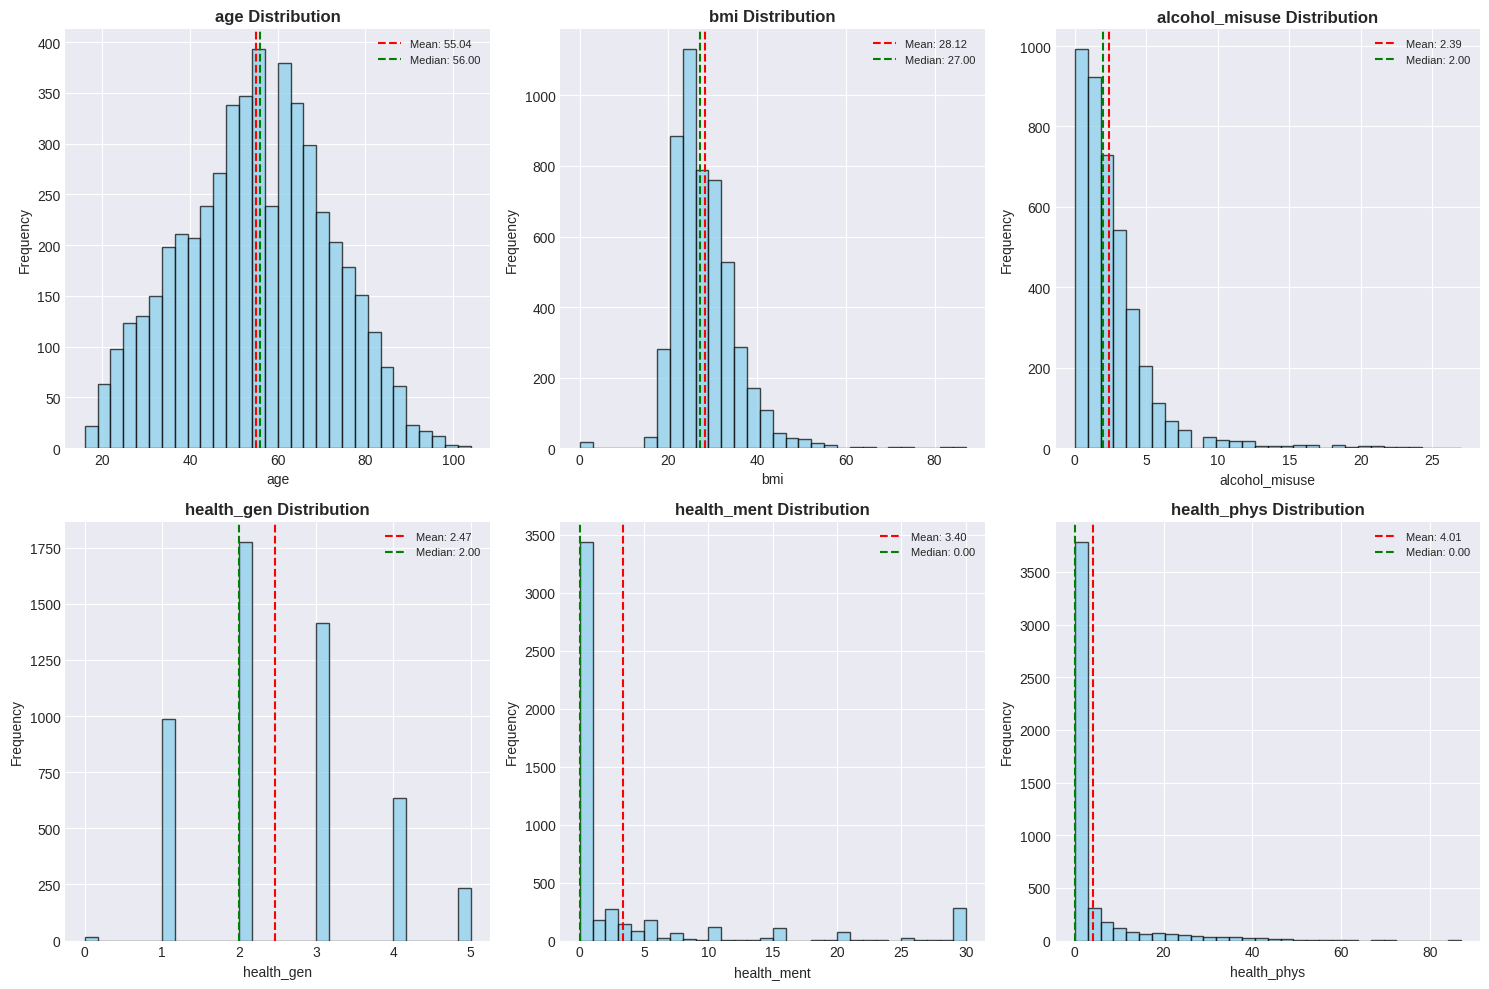

In [12]:
# Distribution of numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    # Remove missing values for plotting
    data = df[col].dropna()

    axes[idx].hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

    # Add mean and median lines
    axes[idx].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
    axes[idx].axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.2f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

A distribution is skewed when it is asymmetrical, meaning one tail is longer than the other. It doesn't have the balanced, bell-shaped form of a normal (Gaussian) distribution.

From the histograms we can see that features like alcohol_misuse, health_phys and health_ment show right skewed distribution. This means that there are many data points clustered on the left (lower values) and fewer, but higher, values pulling the mean to the right. For alcohol_misuse we can see from the distribution that many people report zero or low values for alcohol misuse. For health_ment and health_phys many people report zero or low values of days of poor health, but a few individuals report high values.


When looking at distribution histograms we need to think about how the mean, median and mode behave differently (Central tendency). In a right-skewed distribution, typically **mode < median < mean**. This means that the mean is pulled towards the longer tail (to the right); making the median a more robust and representative measure of the "typical" value. This is important for the imputation strategy as we later opted the **median** for numerical features with skewed distribution as it better reflects the central tendancy without being influnced by any extreme values.

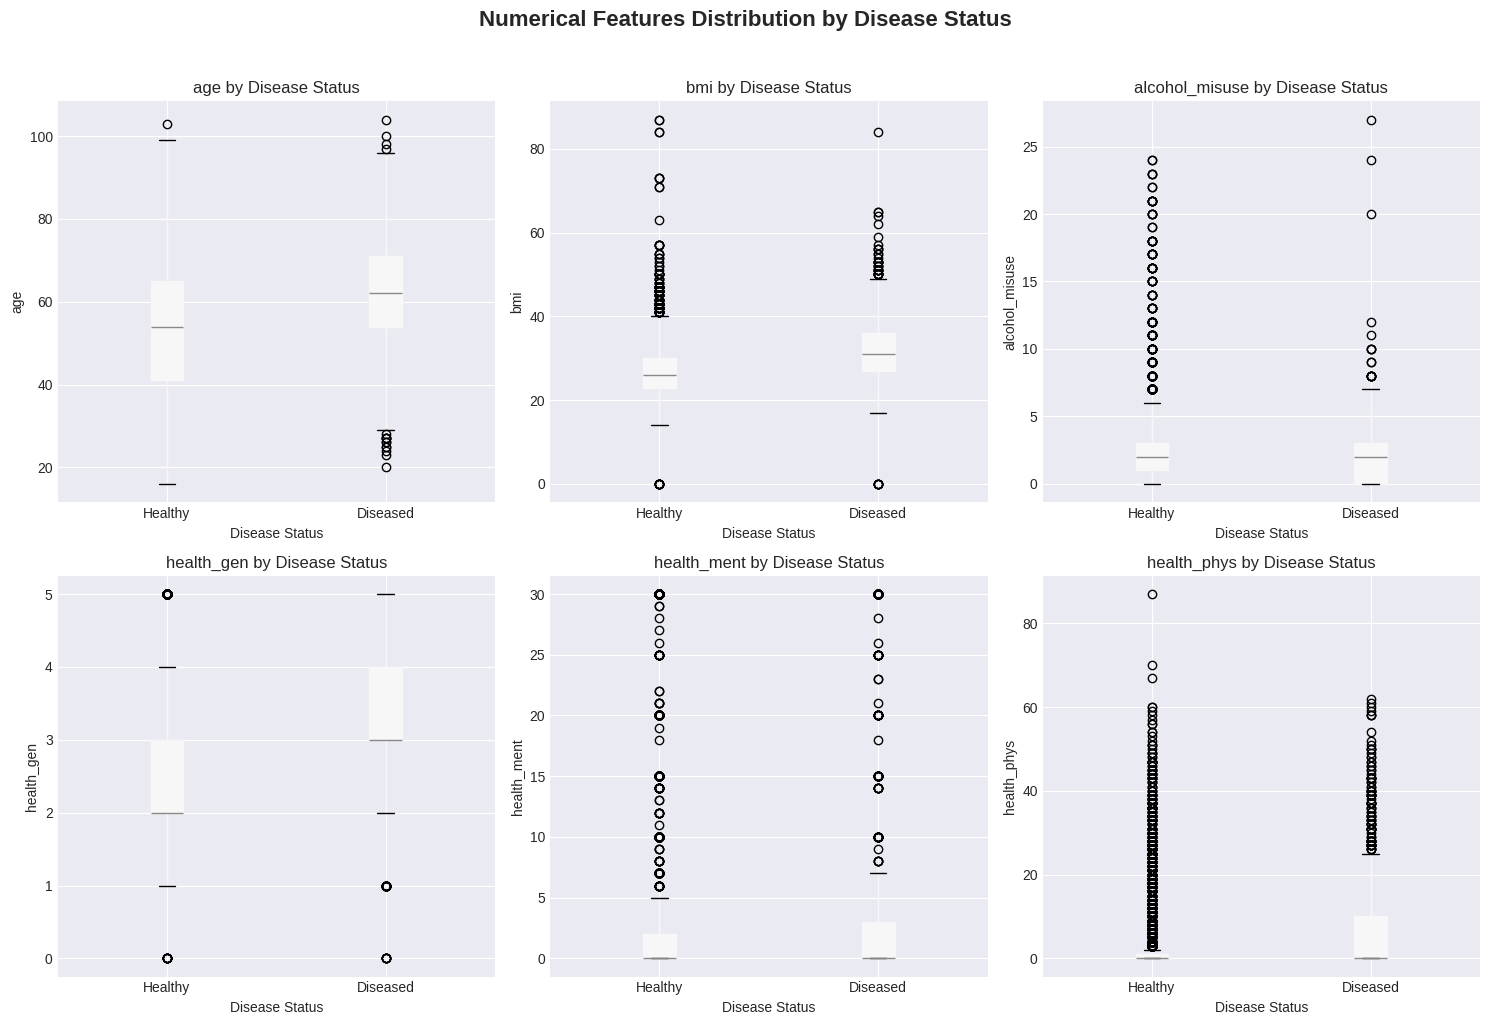

In [13]:
# Box plots to identify outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    df.boxplot(column=col, by=target, ax=axes[idx], patch_artist=True)
    axes[idx].set_title(f'{col} by Disease Status')
    axes[idx].set_xlabel('Disease Status')
    axes[idx].set_ylabel(col)
    plt.sca(axes[idx])
    plt.xticks([1, 2], ['Healthy', 'Diseased'])

plt.suptitle('Numerical Features Distribution by Disease Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

IQR method is used here to detect the outliers because from what we have seen so far, the data is not normally distributed and many features show skewed distribution.

In [61]:
            # Outlier detection using IQR method
print("--- OUTLIER DETECTION (IQR Method) ---")
outlier_summary = {}

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_summary[col] = {
        'count': len(outliers),
        'percentage': (len(outliers) / len(df)) * 100,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

--- OUTLIER DETECTION (IQR Method) ---
                count  percentage  lower_bound  upper_bound
age               2.0    0.039032          8.5        100.5
bmi             234.0    4.566745         13.5         41.5
alcohol_misuse  253.0    4.937549         -2.0          6.0
health_gen      250.0    4.879001          0.5          4.5
health_ment     752.0   14.676034         -3.0          5.0
health_phys     877.0   17.115535         -3.0          5.0


From the IQR analysis we can see that health_ment and health_phys have the highest percentage of outliers. Given the presence of the outliers, the **median** is chosen for numerical imputation. This is because the median is less sensitive to extreme values than the mean which makes it a more robust option to maintain the central tendency of skewed distributions without being disproportionately affected by outliers.


### 2.5 Categorical Features Analysis

Exploring the categorical features distribution and understanding them as well as exploring the number of missing data.

In [62]:
# Distribution of categorical features
print("--- CATEGORICAL FEATURES DISTRIBUTION ---")
for col in categorical_features:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Missing: {df[col].isnull().sum()}")

--- CATEGORICAL FEATURES DISTRIBUTION ---

gender:
gender
female    3719
male      1405
Name: count, dtype: int64
Missing: 0

high_chol:
high_chol
normal    3632
high      1156
Name: count, dtype: int64
Missing: 336

chol_check:
chol_check
checked       4643
notchecked     195
Name: count, dtype: int64
Missing: 286

history_stroke:
history_stroke
False    4937
True      187
Name: count, dtype: int64
Missing: 0

history_heart_disease:
history_heart_disease
False    4706
True      366
Name: count, dtype: int64
Missing: 52

history_smoking:
history_smoking
False    2126
True     1484
Name: count, dtype: int64
Missing: 1514

amount_activity:
amount_activity
active       3162
notactive    1029
Name: count, dtype: int64
Missing: 933

fruits:
fruits
True     3256
False    1763
Name: count, dtype: int64
Missing: 105

vegetables:
vegetables
True     4126
False     886
Name: count, dtype: int64
Missing: 112

walking_diff:
walking_diff
False    4261
True      863
Name: count, dtype: int64
Missing

**What are those features telling us ?**


Is the gender - Female or Male


high_col - " Have you EVER been told by a doctor, nurse or other health professional that your blood cholesterol is high? (binary)"

chol_check - Cholesterol check within past five years (binary)

history_stroke - (Ever told) you had a stroke. (binary)

history_heart_disease Respondents that have ever reported having coronary heart disease (CHD) or myocardial infarction (MI) (binary)


history_smoking - Have you smoked at least 100 cigarettes in your entire life? [Note 5 packs = 100 cigarettes] (binary)


amount_activity - Adults who reported doing physical activity or exercise during the past 30 days other than their regular job (binary)

fruits - Consume Fruit 1 or more times per day (binary)

vegetables - Consume Vegetables 1 or more times per day (binary)

walking_diff - Do you have serious difficulty walking or climbing stairs? (binary)

high_bp - " Adults who have been told they have high blood pressure by a doctor, nurse, or other health professional (binary)"


**Note:** From the categorical distribution we can see the history_smoking has the highest missing number.


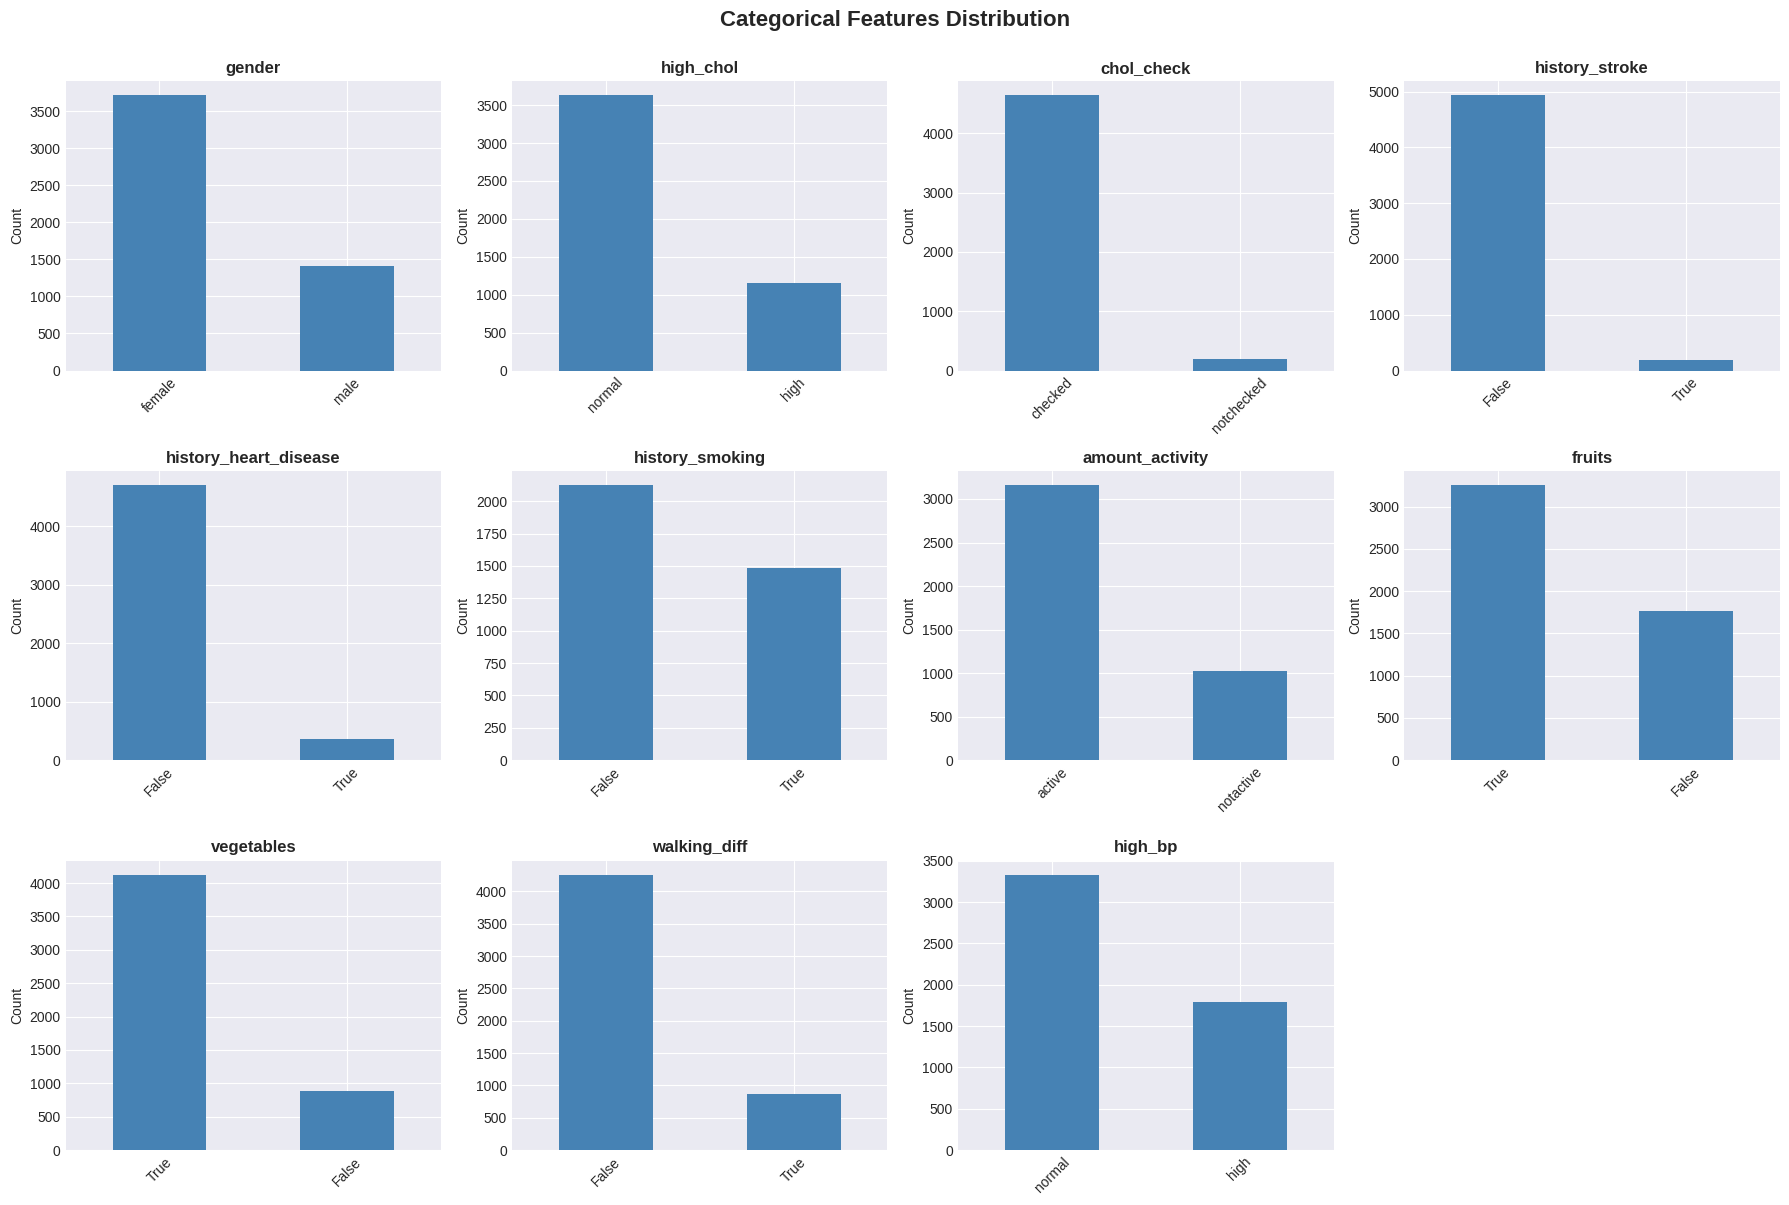

In [16]:
# Visualize categorical features
n_cols = 4
n_rows = (len(categorical_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    df[col].value_counts().plot(kind='bar', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

# Hide extra subplots
for idx in range(len(categorical_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Categorical Features Distribution', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

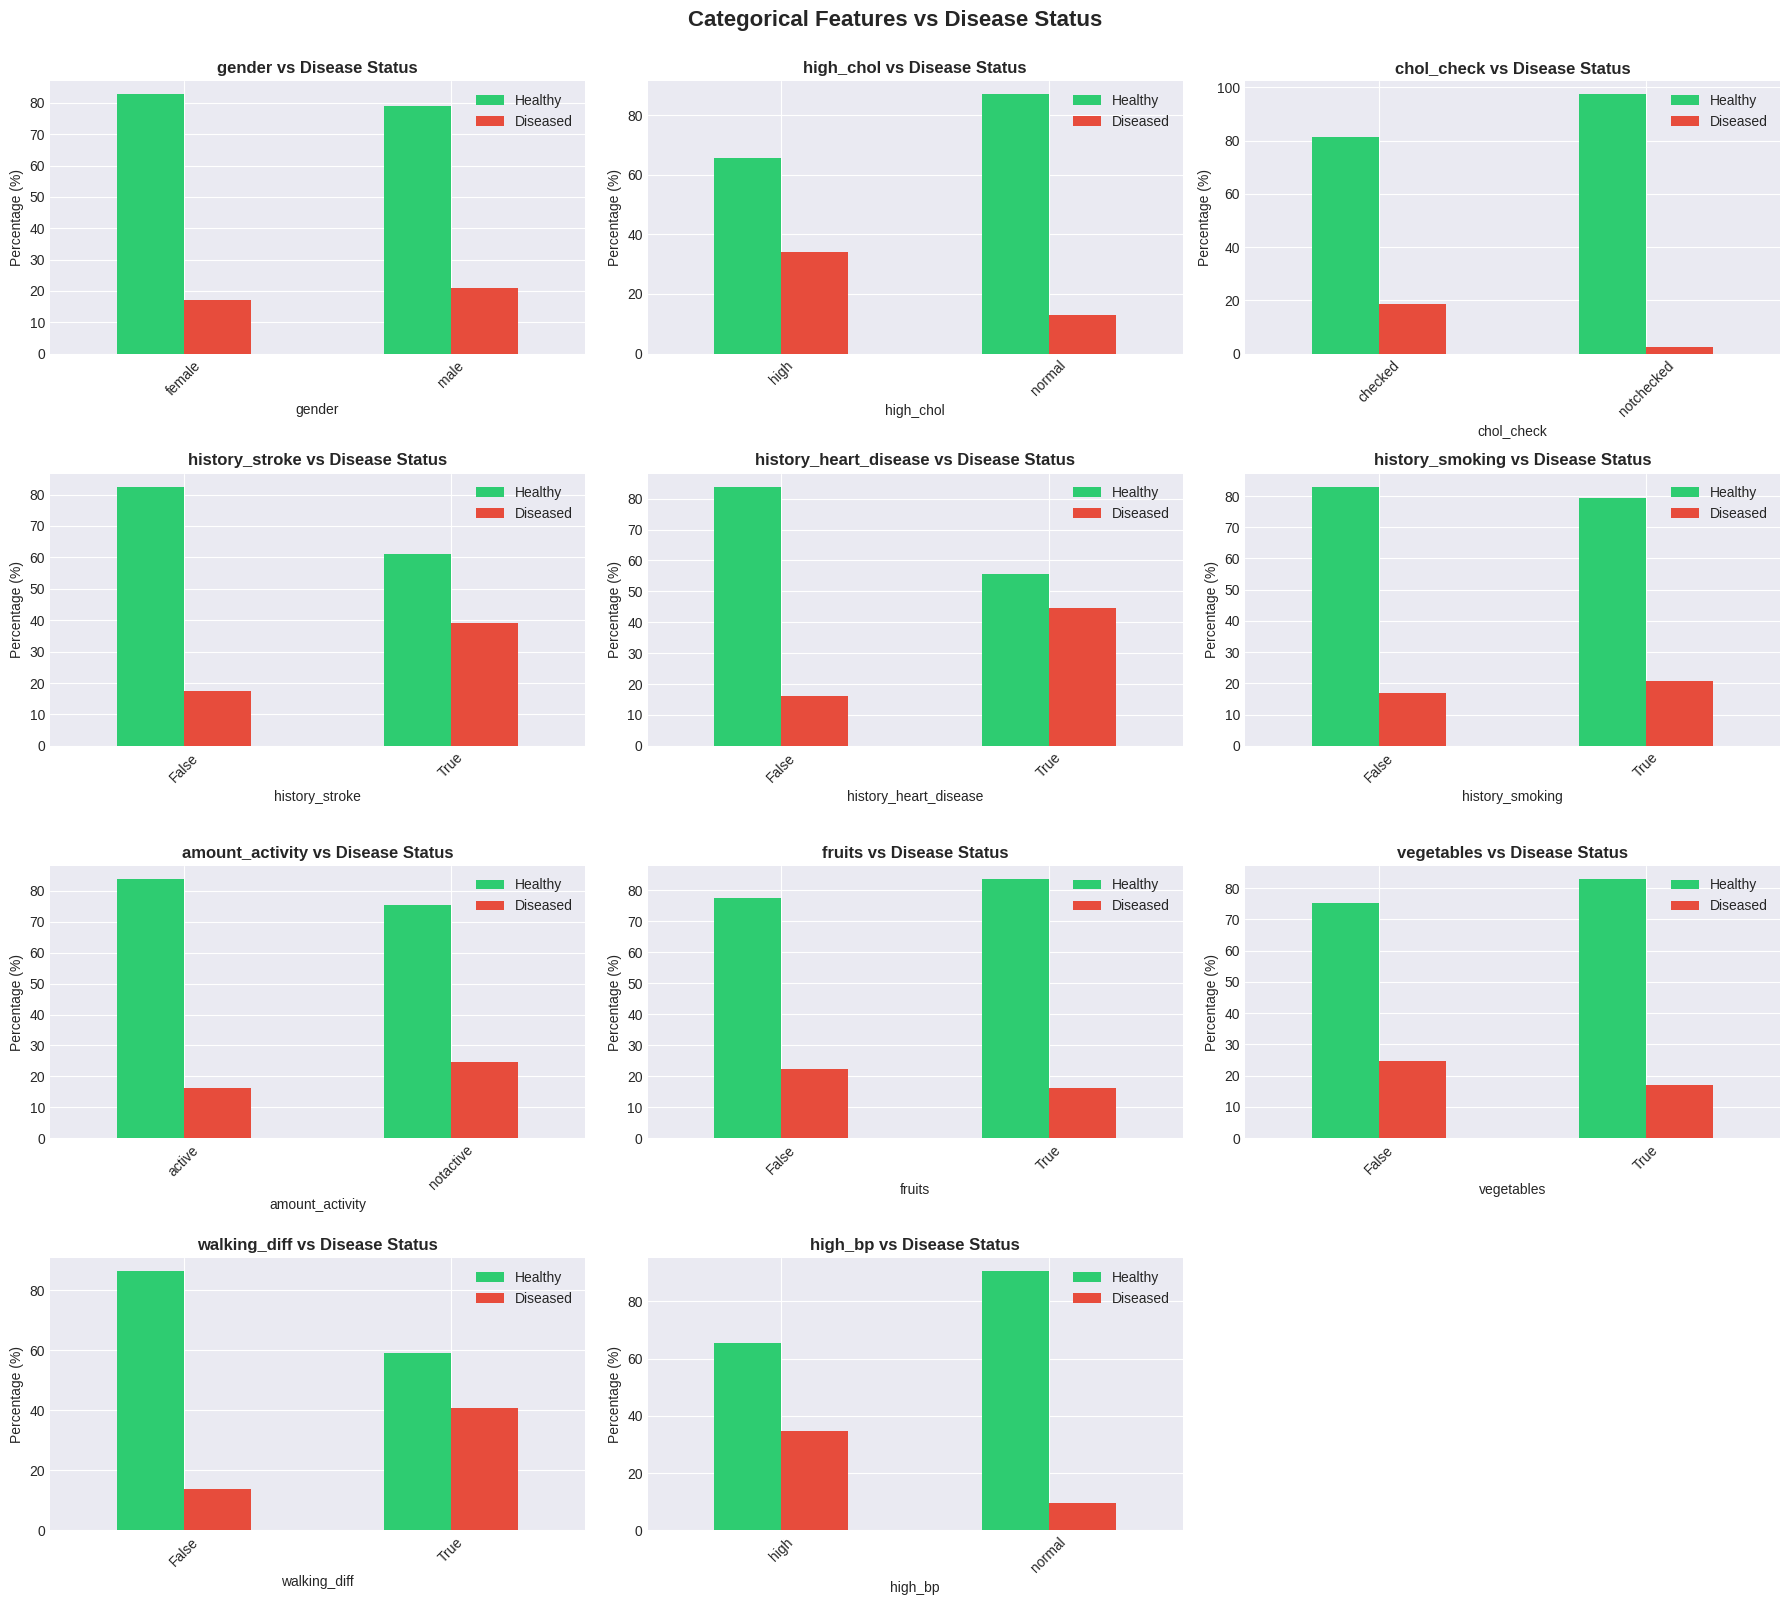

In [17]:
# Categorical features vs target variable
n_cols = 3
n_rows = (len(categorical_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    # Create crosstab
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[idx], stacked=False, color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{col} vs Disease Status', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(['Healthy', 'Diseased'], loc='best')
    axes[idx].tick_params(axis='x', rotation=45)

# Hide extra subplots
for idx in range(len(categorical_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Categorical Features vs Disease Status', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

### 2.6 Correlation Analysis

The aim from this is to understand the linear relationship between all features and the target variable.

the code prepares the data by making all relevant coloumns numerical and then quantify the linear relationships between them. This is then visualised in a heatmap correlation plot. From this we can then identify any potential predictors and check for multicollinearity.  

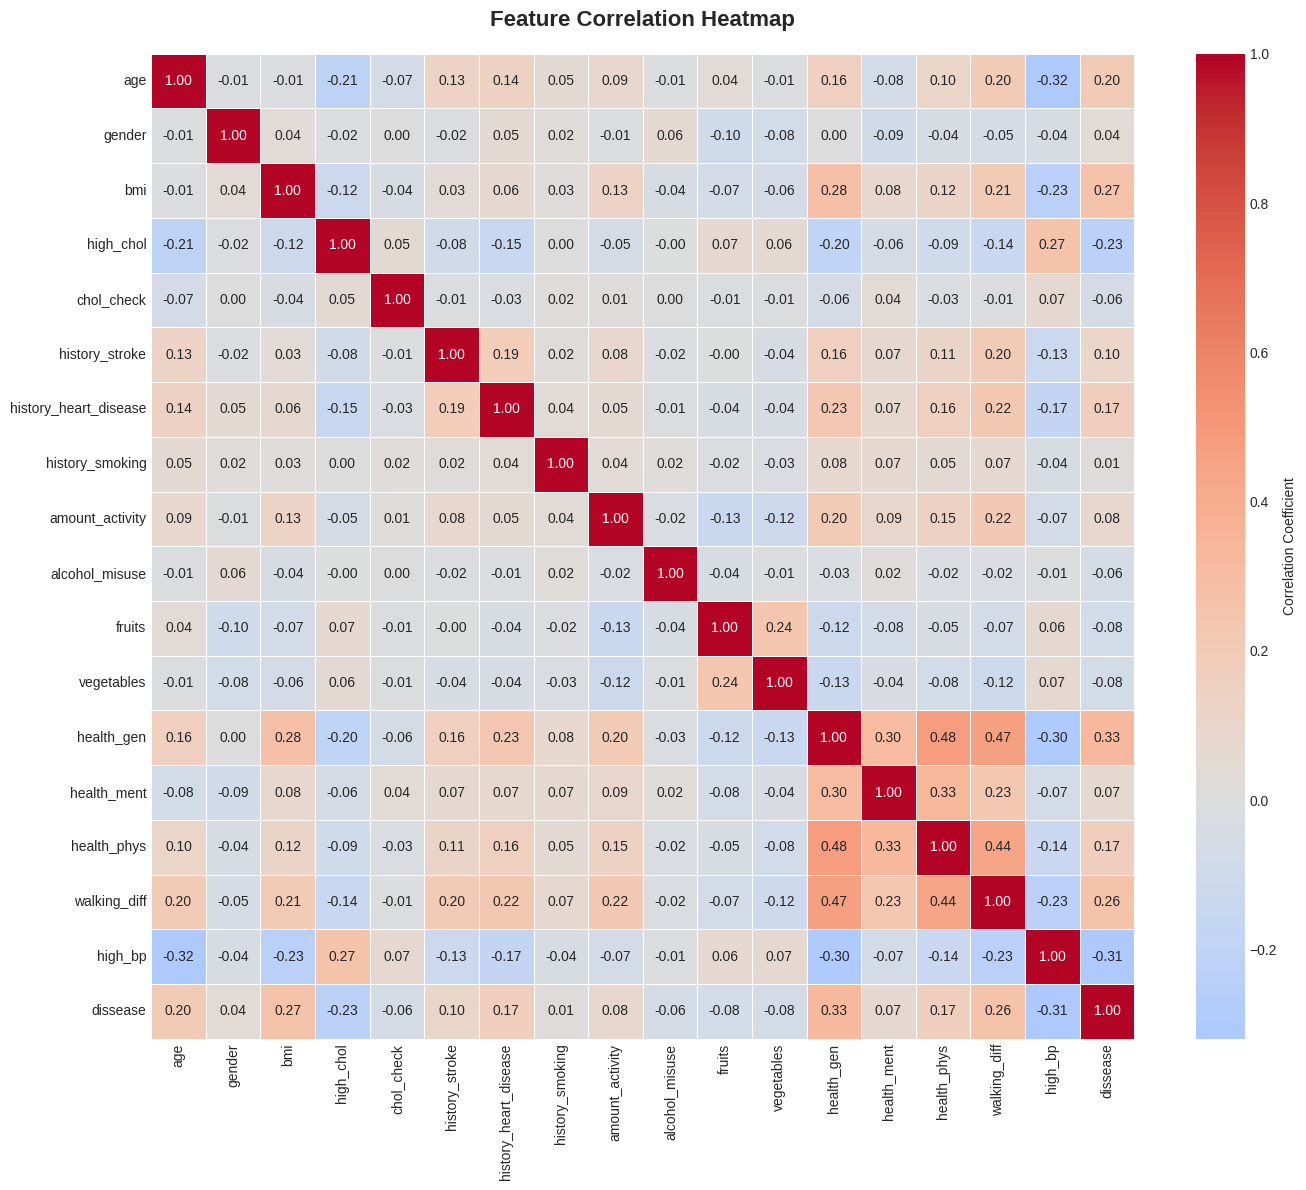

In [18]:
# Create a copy for correlation analysis
df_corr = df.copy()

# Convert categorical variables to numeric for correlation
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_features + [target]:
    if df_corr[col].dtype == 'object' or df_corr[col].dtype == 'bool':
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Calculate correlation matrix
correlation_matrix = df_corr.corr()

# Plot full correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In the next code, we are trying to identify and understand which features have the strongest linear association with the disease status, serving as a basis for further feature selection or model interpretation. Positive correlation features are represented with a green bar, negative correlation features are represented by red bars.

--- FEATURES CORRELATION WITH TARGET ---
health_gen               0.328592
bmi                      0.266146
walking_diff             0.262304
age                      0.204613
history_heart_disease    0.168126
health_phys              0.167791
history_stroke           0.104617
amount_activity          0.084066
health_ment              0.068668
gender                   0.043418
history_smoking          0.011377
chol_check              -0.059557
alcohol_misuse          -0.061846
vegetables              -0.077483
fruits                  -0.078406
high_chol               -0.228820
high_bp                 -0.310426
Name: dissease, dtype: float64


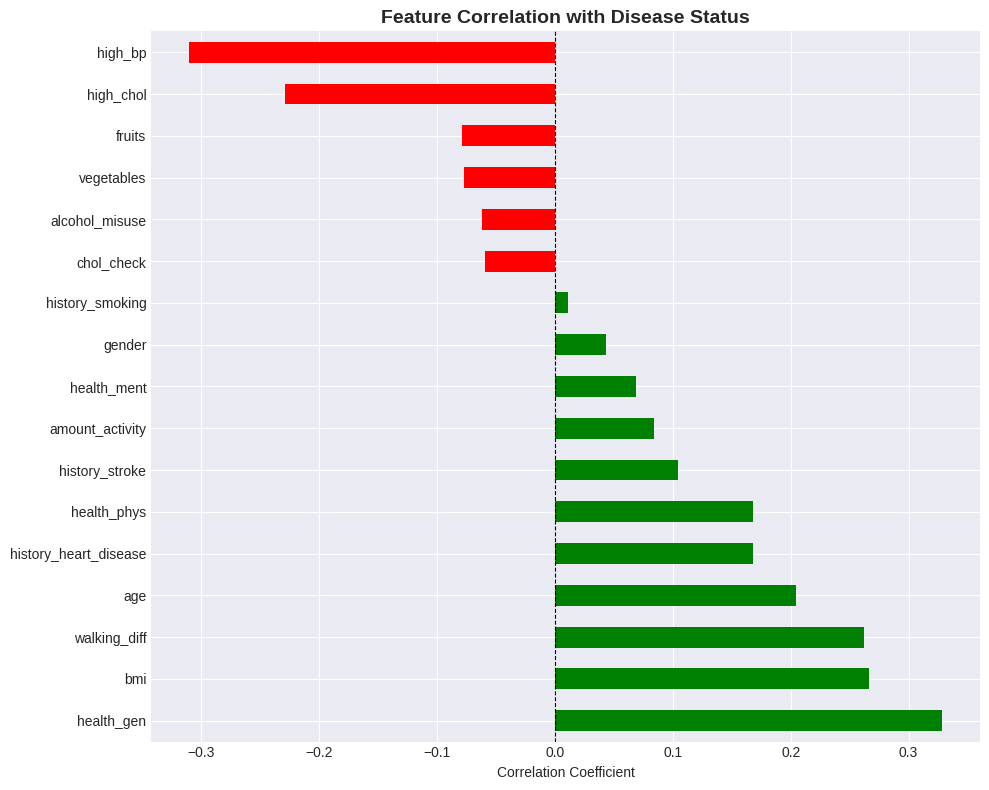

In [63]:
# Correlation with target variable
target_corr = correlation_matrix[target].drop(target).sort_values(ascending=False)

print("--- FEATURES CORRELATION WITH TARGET ---")
print(target_corr)

# Visualize
plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh', color=['green' if x > 0 else 'red' for x in target_corr])
plt.xlabel('Correlation Coefficient')
plt.title('Feature Correlation with Disease Status', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

From the results, we see that the following features have strong linear association with disease status:

health_gen

bmi

walking_diff

age  

history_heart_disease

health_phys

history_stroke

amount_activity

health_ment

gender

history_smoking


_____________________________________________________________

A correlation of 0.7 means that 49% (0.7 squared) of the variance in one variable can be explained by the other. This is a substantial overlap, suggesting that keeping both features might not add much unique information and could potentially introduce redundancy. From the results we see that there are no highly correlated feature pairs found.  

In [65]:
# Identify highly correlated feature pairs (multicollinearity check)
print("HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7)")
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature_1': correlation_matrix.columns[i],
                'Feature_2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df)
    print("\nNote: High correlation between features may indicate multicollinearity.")
else:
    print("No highly correlated feature pairs found.")

HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7)
No highly correlated feature pairs found.


## 3. Data Preprocessing

### 3.1 Strategy for Handling Missing Data

In [68]:
# Create a copy for preprocessing
df_processed = df.copy()

print("MISSING DATA HANDLING STRATEGY ")
print("\nApproach:")
print("1. Numerical features: Impute with median (robust to outliers)")
print("2. Categorical features: Impute with mode (most frequent value)")

print("\nJustification:")
print("- Median for numerical: Less sensitive to outliers than mean")
print("- Mode for categorical: Preserves most common pattern")
print("- Missing data appears to be MAR (Missing At Random)")

MISSING DATA HANDLING STRATEGY 

Approach:
1. Numerical features: Impute with median (robust to outliers)
2. Categorical features: Impute with mode (most frequent value)

Justification:
- Median for numerical: Less sensitive to outliers than mean
- Mode for categorical: Preserves most common pattern
- Missing data appears to be MAR (Missing At Random)


In [69]:
# Method: Simple Imputation
from sklearn.impute import SimpleImputer

# For numerical features
num_imputer = SimpleImputer(strategy='median')
df_processed[numerical_features] = num_imputer.fit_transform(df_processed[numerical_features])

# For categorical features
cat_imputer = SimpleImputer(strategy='most_frequent')
df_processed[categorical_features] = cat_imputer.fit_transform(df_processed[categorical_features])

print("\n --- AFTER IMPUTATION ---")
print(f"Missing values remaining: {df_processed.isnull().sum().sum()}")
print("\nConfirming no missing data:")
print(df_processed.isnull().sum())


 --- AFTER IMPUTATION ---
Missing values remaining: 0

Confirming no missing data:
age                      0
gender                   0
bmi                      0
high_chol                0
chol_check               0
history_stroke           0
history_heart_disease    0
history_smoking          0
amount_activity          0
alcohol_misuse           0
fruits                   0
vegetables               0
health_gen               0
health_ment              0
health_phys              0
walking_diff             0
high_bp                  0
dissease                 0
dtype: int64


### 3.2 Feature Engineering

The following code converts all the non-nmerical features and the target variable, disease , into a numerical format. This is a necessary step before feeding the data into ML algorithms.

In [23]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

df_encoded = df_processed.copy()
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Encode target variable
df_encoded[target] = LabelEncoder().fit_transform(df_encoded[target])

print("Categorical variables encoded successfully!")
print("\nEncoded dataset shape:", df_encoded.shape)
df_encoded.head()

Categorical variables encoded successfully!

Encoded dataset shape: (5124, 18)


,age,gender,bmi,high_chol,chol_check,history_stroke,history_heart_disease,history_smoking,amount_activity,alcohol_misuse,fruits,vegetables,health_gen,health_ment,health_phys,walking_diff,high_bp,dissease
0,68.0,0,20.0,1,0,0,0,0,0,2.0,1,1,1.0,0.0,0.0,0,1,0
1,54.0,0,47.0,1,0,0,0,1,0,1.0,1,1,3.0,0.0,0.0,0,1,0
2,55.0,0,30.0,1,0,0,0,0,0,0.0,1,1,1.0,0.0,0.0,0,0,0
3,44.0,0,19.0,1,1,0,0,0,0,6.0,1,1,3.0,20.0,6.0,0,1,0
4,61.0,1,32.0,1,0,0,0,0,0,2.0,1,1,2.0,0.0,0.0,1,1,0


### 3.3 Train-Test Split

Data is divided into 80% training (allowing models to learn robust patterns and relationshsips from the available data)  and 20% testing ( This small portion is used only for the final evalution of the trained models. ensuring the models ability to predit on data that it has never encountered during training). We also stratified due to class imbalance in the disease target variable. This ensures that target varialbe has a fair representation across the data.

In [70]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

# Split: 80% training, 20% testing
# Stratify to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- TRAIN-TEST SPLIT ---")
print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nFeatures: {X_train.shape[1]}")

print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

--- TRAIN-TEST SPLIT ---
Training set size: 4099 samples (80.0%)
Test set size: 1025 samples (20.0%)

Features: 17

Class distribution in training set:
dissease
0    3350
1     749
Name: count, dtype: int64

Class distribution in test set:
dissease
0    838
1    187
Name: count, dtype: int64


### 3.4 Feature Scaling

This code evaluates the performance of all trained machine learning models on the test set. The test set contains data that the models have never seen before, thus, it will give an unbiased estimate of how well they will perform in the reall world. This step involves standardising the features making them have a mean of 0 and a standard deviation of 1. Scaling ensures that all features contribute approximately equally to the models decision making process; preventing features with naturally larger values from dominating. Feature scaling is important for supervised analysis and unsupervised analysis.  

In [25]:
from sklearn.preprocessing import StandardScaler

# Standardize features (important for distance-based algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier interpretation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling completed!")
print("\nScaled training set (first 5 rows):")
X_train_scaled.head()

Feature scaling completed!

Scaled training set (first 5 rows):


,age,gender,bmi,high_chol,chol_check,history_stroke,history_heart_disease,history_smoking,amount_activity,alcohol_misuse,fruits,vegetables,health_gen,health_ment,health_phys,walking_diff,high_bp
4909,1.448507,1.610113,-0.738054,0.542104,-0.201543,-0.19624,-0.279494,-0.638076,-0.505407,0.664404,0.730007,0.461218,-0.429263,-0.437839,-0.410835,-0.452636,0.735118
2765,-1.268437,1.610113,1.136794,0.542104,-0.201543,-0.19624,-0.279494,-0.638076,-0.505407,-0.899865,0.730007,0.461218,-0.429263,-0.437839,-0.304916,-0.452636,-1.360326
4720,-0.181660,1.610113,-0.738054,0.542104,-0.201543,-0.19624,-0.279494,-0.638076,-0.505407,-0.117730,0.730007,0.461218,-1.352427,-0.437839,-0.410835,-0.452636,-1.360326
4192,-1.811826,-0.621075,1.569452,0.542104,4.961729,-0.19624,-0.279494,1.567213,1.978603,0.664404,0.730007,0.461218,-0.429263,0.459832,-0.410835,-0.452636,0.735118
4738,-1.147684,-0.621075,0.559918,0.542104,-0.201543,-0.19624,-0.279494,1.567213,1.978603,-0.899865,-1.369851,0.461218,-0.429263,-0.437839,-0.410835,-0.452636,-1.360326


## 4. Unsupervised Learning Analysis

### 4.1 Principal Component Analysis (PCA)

PCA helps reduce the number of features in the dataset whilst still retaining as much variance (spread of data) as possible.

In [71]:
from sklearn.decomposition import PCA

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("--- PCA ANALYSIS ---")
print(f"Number of components: {len(explained_variance)}")
print(f"\nVariance explained by first 5 components:")
for i in range(min(5, len(explained_variance))):
    print(f"PC{i+1}: {explained_variance[i]*100:.2f}%")
print(f"\nCumulative variance (first 5 PCs): {cumulative_variance[4]*100:.2f}%")

--- PCA ANALYSIS ---
Number of components: 17

Variance explained by first 5 components:
PC1: 17.43%
PC2: 8.42%
PC3: 7.97%
PC4: 6.49%
PC5: 6.07%

Cumulative variance (first 5 PCs): 46.38%


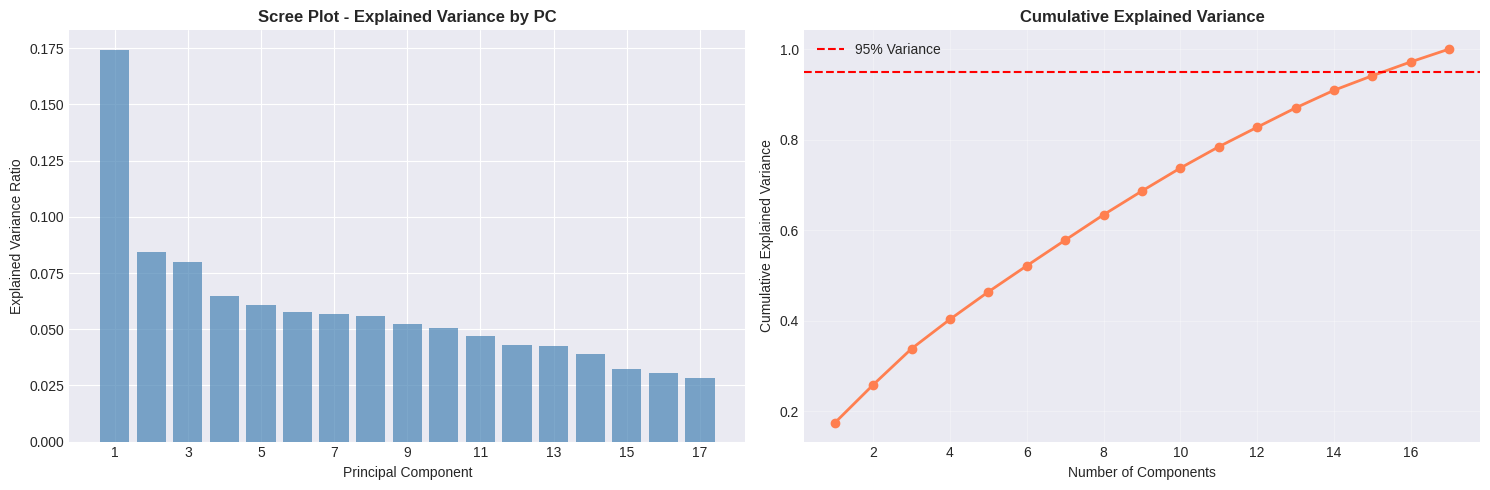


Number of components needed for 95% variance: 16


In [27]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot - Explained Variance by PC', fontweight='bold')
axes[0].set_xticks(range(1, len(explained_variance)+1, 2))

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance,
             marker='o', linestyle='-', color='coral', linewidth=2)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components needed for 95% variance: {n_components_95}")

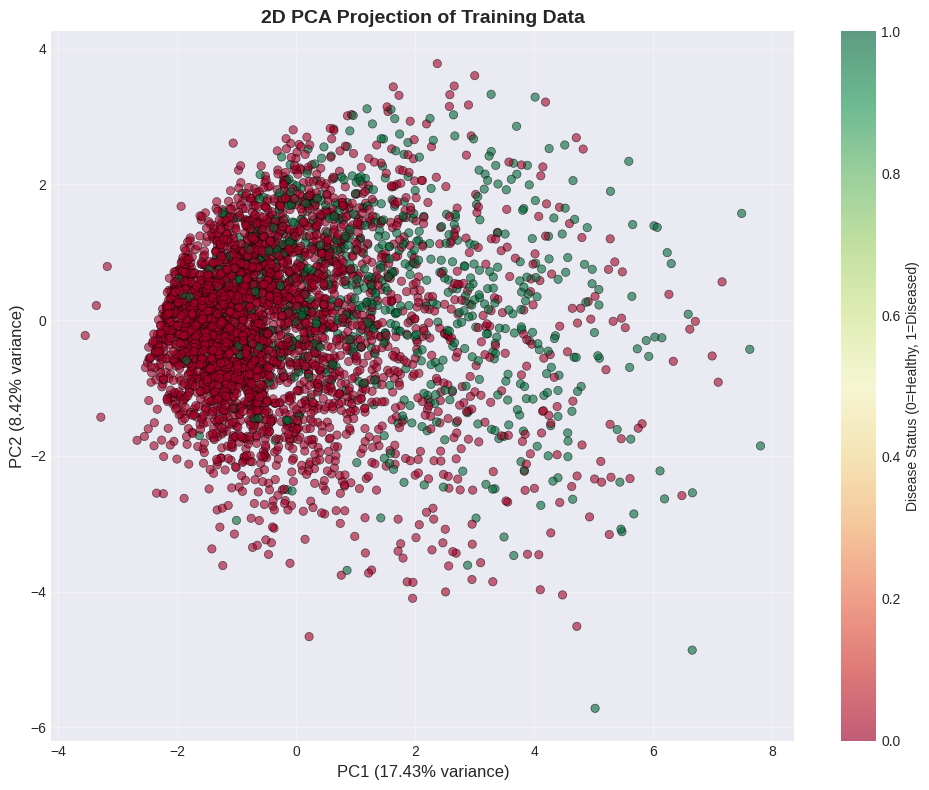

In [28]:
# 2D PCA visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=y_train, cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=12)
plt.title('2D PCA Projection of Training Data', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Disease Status (0=Healthy, 1=Diseased)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Clustering Analysis - K-Means

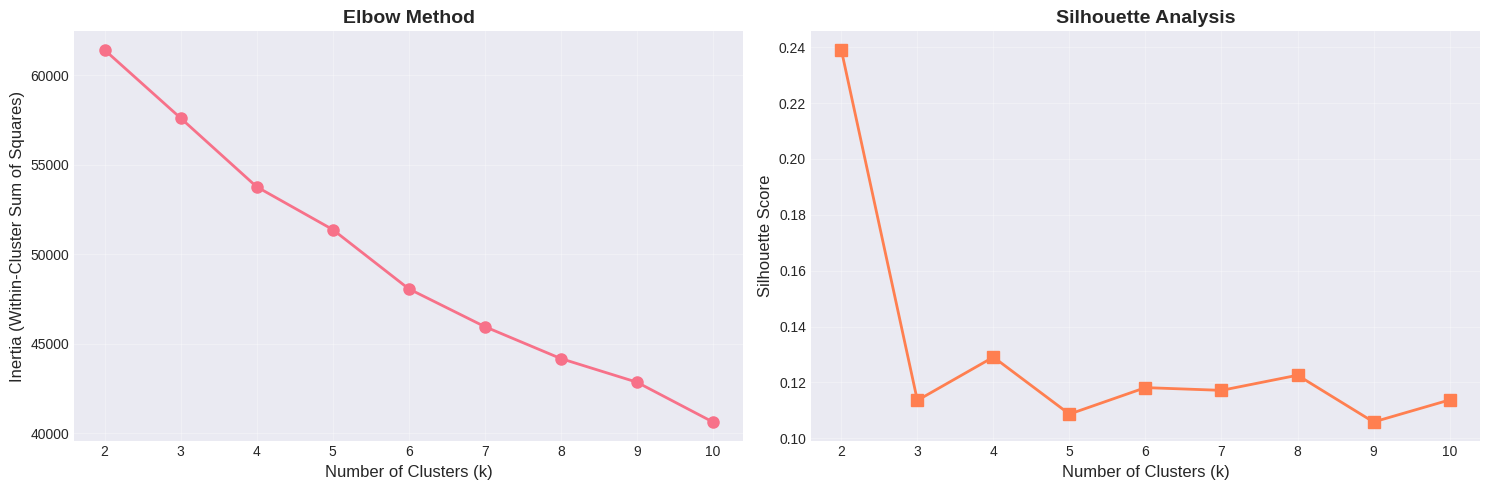


Recommended number of clusters (highest silhouette): 2


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, marker='o', linestyle='-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method', fontweight='bold', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='s', linestyle='-',
             linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontweight='bold', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Recommend optimal k
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nRecommended number of clusters (highest silhouette): {optimal_k}")

In [72]:
# Perform K-Means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_train_scaled)

print("--- K-MEANS CLUSTERING RESULTS ---")
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_train_scaled, cluster_labels):.3f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(X_train_scaled, cluster_labels):.3f}")
print("(Lower Davies-Bouldin is better)")

print("\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

--- K-MEANS CLUSTERING RESULTS ---
Number of clusters: 2
Silhouette Score: 0.239
Davies-Bouldin Score: 2.400
(Lower Davies-Bouldin is better)

Cluster sizes:
0     925
1    3174
Name: count, dtype: int64


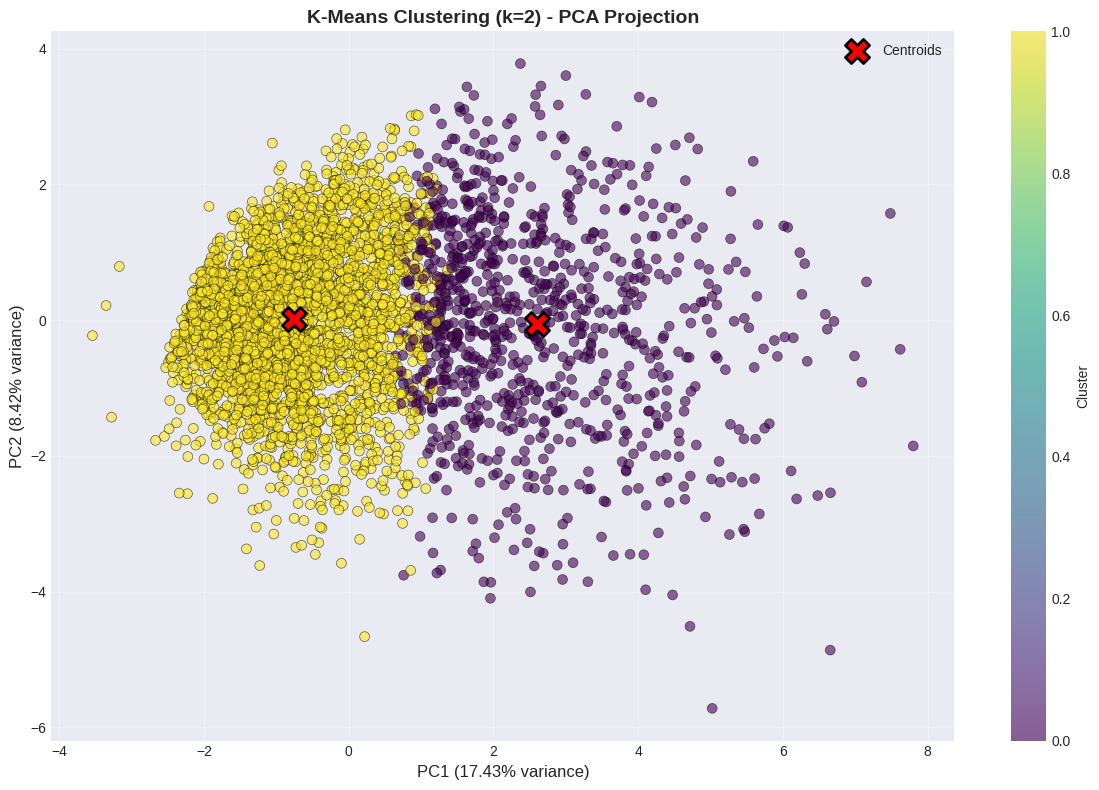

In [31]:
# Visualize clusters in 2D PCA space
plt.figure(figsize=(12, 8))

# Plot clusters
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=cluster_labels, cmap='viridis',
                     alpha=0.6, edgecolors='black', linewidth=0.5, s=50)

# Plot centroids in PCA space
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           marker='X', s=300, c='red', edgecolors='black', linewidth=2,
           label='Centroids')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=12)
plt.title(f'K-Means Clustering (k={optimal_k}) - PCA Projection', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 CLUSTER vs DISEASE STATUS 
Disease Status     0    1
Cluster                  
0                523  402
1               2827  347


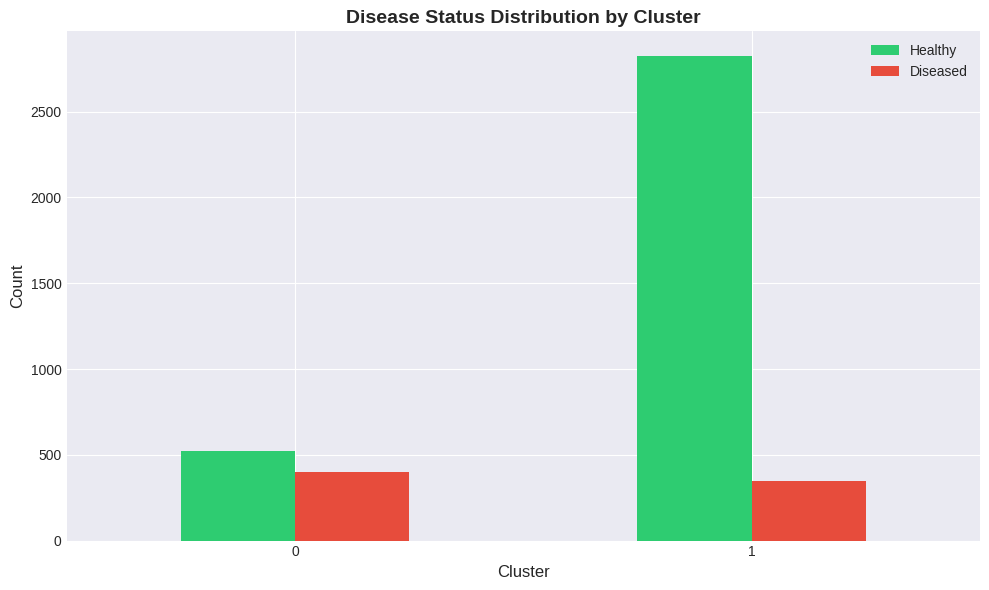


Interpretation: Do clusters align with disease status?
If clusters show distinct disease patterns, it suggests natural patient subgroups.


In [73]:
# Compare clusters with actual disease labels
cluster_disease_comparison = pd.crosstab(
    pd.Series(cluster_labels, name='Cluster'),
    pd.Series(y_train.values, name='Disease Status')
)

print(" CLUSTER vs DISEASE STATUS ")
print(cluster_disease_comparison)

# Visualize
cluster_disease_comparison.plot(kind='bar', stacked=False, figsize=(10, 6),
                                color=['#2ecc71', '#e74c3c'])
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Disease Status Distribution by Cluster', fontsize=14, fontweight='bold')
plt.legend(['Healthy', 'Diseased'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nInterpretation: Do clusters align with disease status?")
print("If clusters show distinct disease patterns, it suggests natural patient subgroups.")

## 5. Supervised Learning - Classification Models

### 5.1 Model Training

In [76]:
# Import classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Initialize models WITH REGULARIZATION (to prevent overfitting)
models = {
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=5,           # Limit tree depth
        min_samples_split=50,  # Minimum samples to split
        min_samples_leaf=20    # Minimum samples in leaf
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=10,          # Limit each tree depth
        min_samples_split=20,  # Minimum samples to split
        min_samples_leaf=10    # Minimum samples in leaf
    ),
}

print(" MODELS TO TRAIN ")
for i, name in enumerate(models.keys(), 1):
    print(f"{i}. {name}")
print("\n ** Models initialized with regularization parameters **")


 MODELS TO TRAIN 
1. Decision Tree
2. Random Forest

 ** Models initialized with regularization parameters **


In [77]:
# Train all models
trained_models = {}

print("Training models...\n")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f" {name} trained successfully")

print("\nAll models trained!")

Training models...

Training Decision Tree...
 Decision Tree trained successfully
Training Random Forest...
 Random Forest trained successfully

All models trained!


### 5.2 Model Evaluation - Training Performance

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

# Evaluate on training set
train_results = []

for name, model in trained_models.items():
    y_train_pred = model.predict(X_train_scaled)
    y_train_proba = model.predict_proba(X_train_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    train_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_train, y_train_pred),
        'Precision': precision_score(y_train, y_train_pred),
        'Recall': recall_score(y_train, y_train_pred),
        'F1-Score': f1_score(y_train, y_train_pred),
        'ROC-AUC': roc_auc_score(y_train, y_train_proba) if y_train_proba is not None else None
    })

train_results_df = pd.DataFrame(train_results)
train_results_df = train_results_df.sort_values('F1-Score', ascending=False)

print("TRAINING SET PERFORMANCE ")
print(train_results_df.to_string(index=False))

TRAINING SET PERFORMANCE 
        Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Random Forest  0.862405   0.824561 0.313752  0.454545 0.893797
Decision Tree  0.837521   0.654275 0.234980  0.345776 0.840185


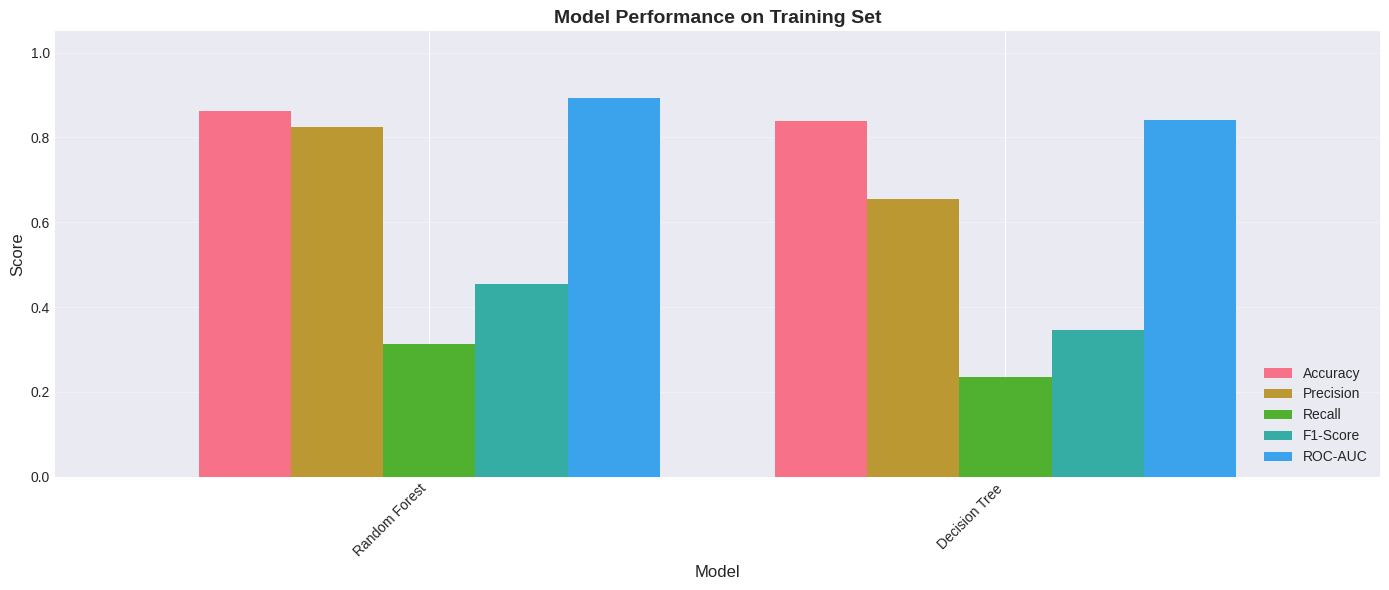

In [36]:
# Visualize training performance
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
train_results_plot = train_results_df.set_index('Model')[metrics_to_plot]

train_results_plot.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance on Training Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim([0, 1.05])
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Cross-Validation

In [88]:
from sklearn.model_selection import cross_val_score, cross_validate

# Perform 5-fold cross-validation
cv_results = []
cv_folds = 5

print(f"Performing {cv_folds}-fold cross-validation...\n")

for name, model in trained_models.items():
    print(f"Evaluating {name}...")

    # Multiple scoring metrics
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    scores = cross_validate(model, X_train_scaled, y_train,
                           cv=cv_folds, scoring=scoring, n_jobs=-1)

    cv_results.append({
        'Model': name,
        'Accuracy_Mean': scores['test_accuracy'].mean(),
        'Accuracy_Std': scores['test_accuracy'].std(),
        'Precision_Mean': scores['test_precision'].mean(),
        'Precision_Std': scores['test_precision'].std(),
        'Recall_Mean': scores['test_recall'].mean(),
        'Recall_Std': scores['test_recall'].std(),
        'F1_Mean': scores['test_f1'].mean(),
        'F1_Std': scores['test_f1'].std(),
        'ROC_AUC_Mean': scores['test_roc_auc'].mean(),
        'ROC_AUC_Std': scores['test_roc_auc'].std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values('F1_Mean', ascending=False)

print("CROSS-VALIDATION RESULTS ")
print(cv_results_df[['Model', 'Accuracy_Mean', 'Accuracy_Std',
                     'F1_Mean', 'F1_Std', 'ROC_AUC_Mean', 'ROC_AUC_Std']].to_string(index=False))

Performing 5-fold cross-validation...

Evaluating Decision Tree...
Evaluating Random Forest...
CROSS-VALIDATION RESULTS 
        Model  Accuracy_Mean  Accuracy_Std  F1_Mean   F1_Std  ROC_AUC_Mean  ROC_AUC_Std
Random Forest       0.833618      0.006622 0.324628 0.026745      0.821942     0.011694
Decision Tree       0.825322      0.008487 0.305444 0.049670      0.801745     0.010572


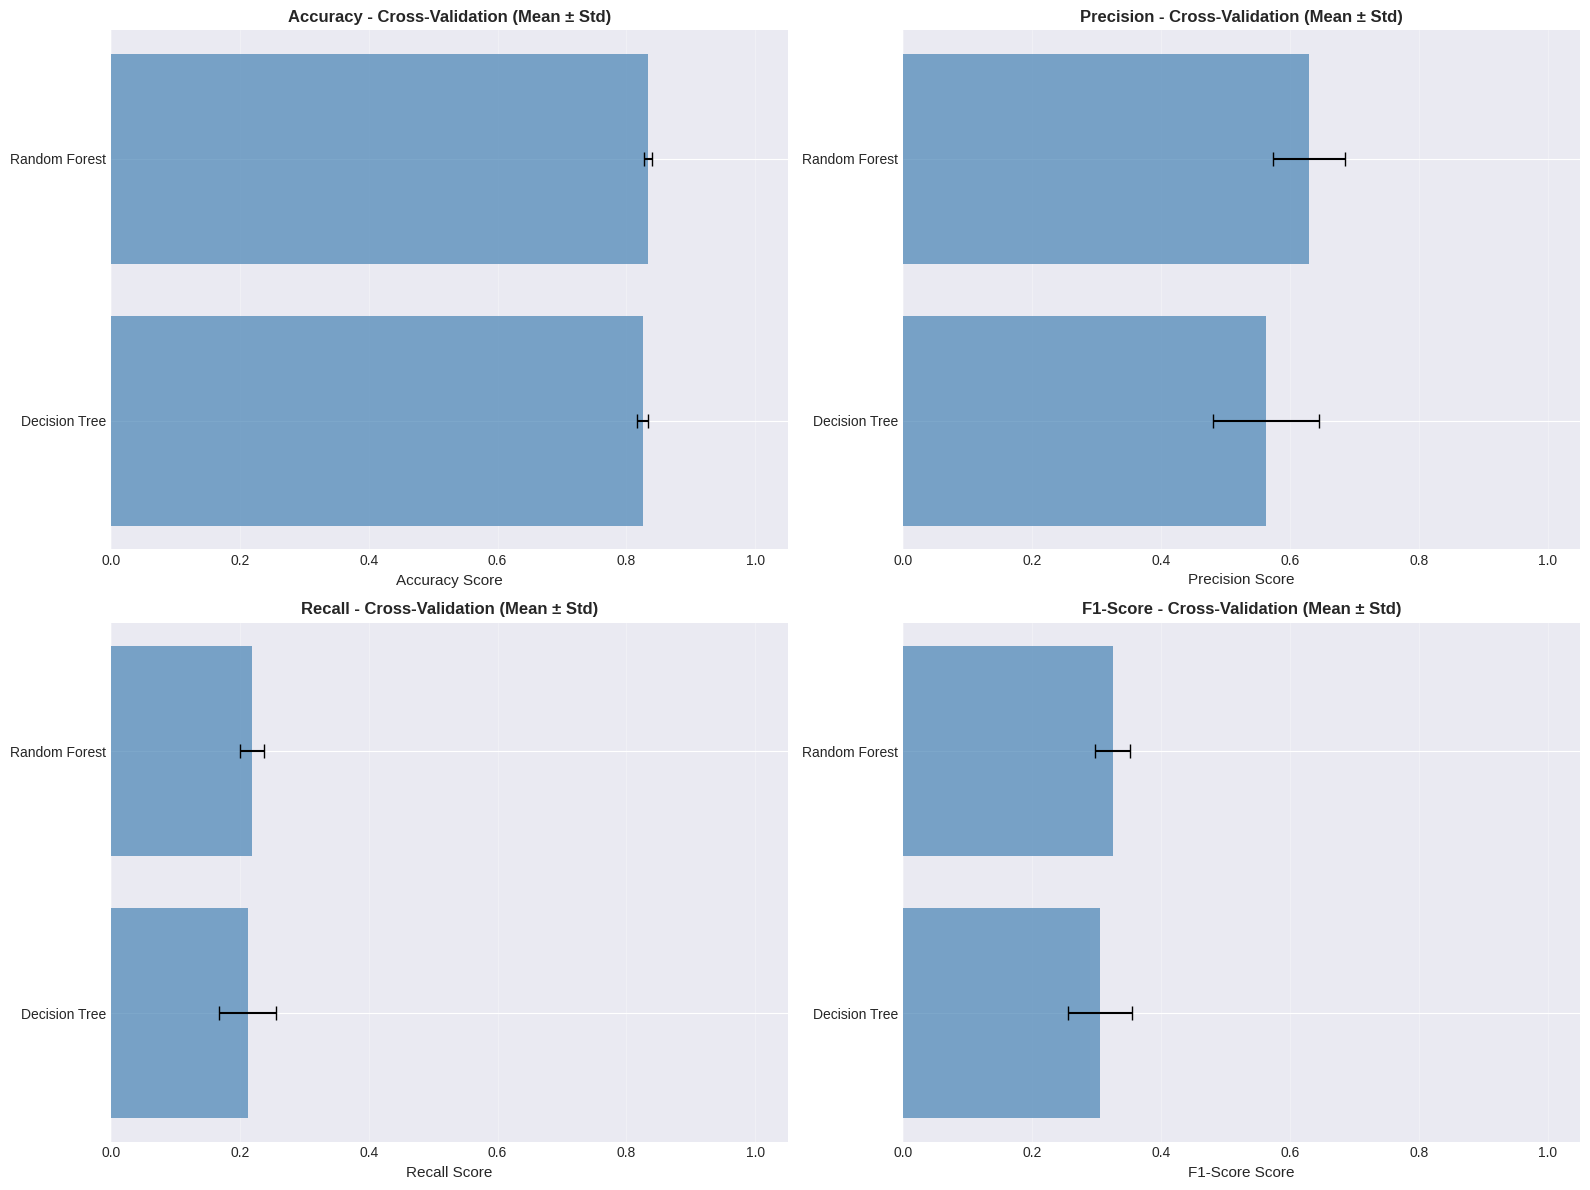

In [38]:
# Visualize cross-validation results with error bars
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

metrics = [('Accuracy', 'Accuracy_Mean', 'Accuracy_Std'),
           ('Precision', 'Precision_Mean', 'Precision_Std'),
           ('Recall', 'Recall_Mean', 'Recall_Std'),
           ('F1-Score', 'F1_Mean', 'F1_Std')]

for idx, (metric_name, mean_col, std_col) in enumerate(metrics):
    data = cv_results_df.sort_values(mean_col, ascending=True)
    axes[idx].barh(data['Model'], data[mean_col], xerr=data[std_col],
                   capsize=5, alpha=0.7, color='steelblue')
    axes[idx].set_xlabel(f'{metric_name} Score', fontsize=11)
    axes[idx].set_title(f'{metric_name} - Cross-Validation (Mean ± Std)',
                       fontweight='bold', fontsize=12)
    axes[idx].set_xlim([0, 1.05])
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Test Set Performance

In [89]:
# Evaluate on test set
test_results = []

for name, model in trained_models.items():
    y_test_pred = model.predict(X_test_scaled)
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1-Score': f1_score(y_test, y_test_pred),
        'ROC-AUC': roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else None
    })

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values('F1-Score', ascending=False)

print("TEST SET PERFORMANCE ")
print(test_results_df.to_string(index=False))

TEST SET PERFORMANCE 
        Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Random Forest  0.832195   0.608696 0.224599  0.328125 0.813204
Decision Tree  0.830244   0.622642 0.176471  0.275000 0.779574


In [94]:
# Compare training vs test performance
comparison_data = []

for train_row, test_row in zip(train_results, test_results):
    comparison_data.append({
        'Model': train_row['Model'],
        'Train_F1': train_row['F1-Score'],
        'Test_F1': test_row['F1-Score'],
        'Difference': train_row['F1-Score'] - test_row['F1-Score']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test_F1', ascending=False)

print("TRAINING vs TEST PERFORMANCE (F1-Score) ")
print(comparison_df.to_string(index=False))
print("\n** Note: Large positive difference indicates overfitting **")

TRAINING vs TEST PERFORMANCE (F1-Score) 
        Model  Train_F1  Test_F1  Difference
Random Forest  0.454545 0.328125    0.126420
Decision Tree  0.345776 0.275000    0.070776

** Note: Large positive difference indicates overfitting **


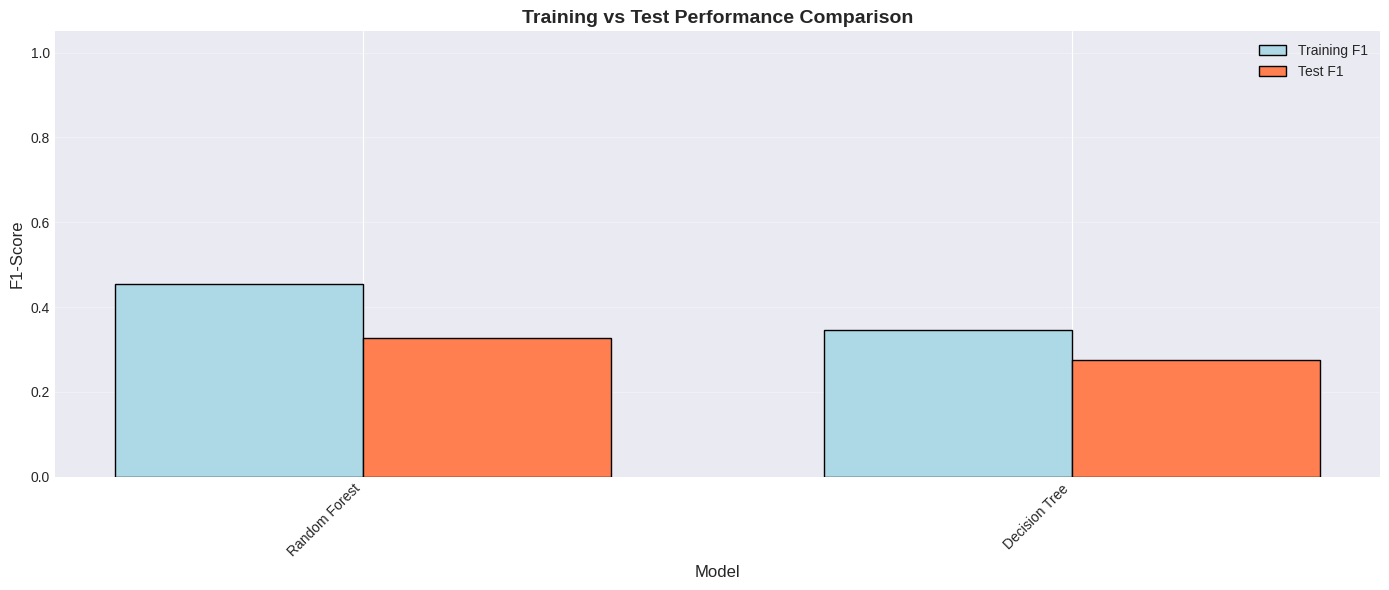

In [41]:
# Visualize training vs test comparison
x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, comparison_df['Train_F1'], width,
               label='Training F1', color='lightblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['Test_F1'], width,
               label='Test F1', color='coral', edgecolor='black')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Training vs Test Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.5 Overfitting Analysis

In [95]:
# Analyze overfitting
print(" OVERFITTING ANALYSIS ")
print("\nOverfitting indicators (Train F1 - Test F1 > 0.05):")

overfitting_threshold = 0.05
overfitting_models = comparison_df[comparison_df['Difference'] > overfitting_threshold]

if len(overfitting_models) > 0:
    print(overfitting_models[['Model', 'Train_F1', 'Test_F1', 'Difference']].to_string(index=False))
else:
    print("No significant overfitting detected.")

print("\nGeneralization performance (Test F1 / Train F1):")
comparison_df['Generalization_Ratio'] = comparison_df['Test_F1'] / comparison_df['Train_F1']
print(comparison_df[['Model', 'Generalization_Ratio']].to_string(index=False))
print("\nNote: Ratio close to 1.0 indicates good generalization.")

 OVERFITTING ANALYSIS 

Overfitting indicators (Train F1 - Test F1 > 0.05):
        Model  Train_F1  Test_F1  Difference
Random Forest  0.454545 0.328125    0.126420
Decision Tree  0.345776 0.275000    0.070776

Generalization performance (Test F1 / Train F1):
        Model  Generalization_Ratio
Random Forest              0.721875
Decision Tree              0.795313

Note: Ratio close to 1.0 indicates good generalization.


### 5.6 Confusion Matrices

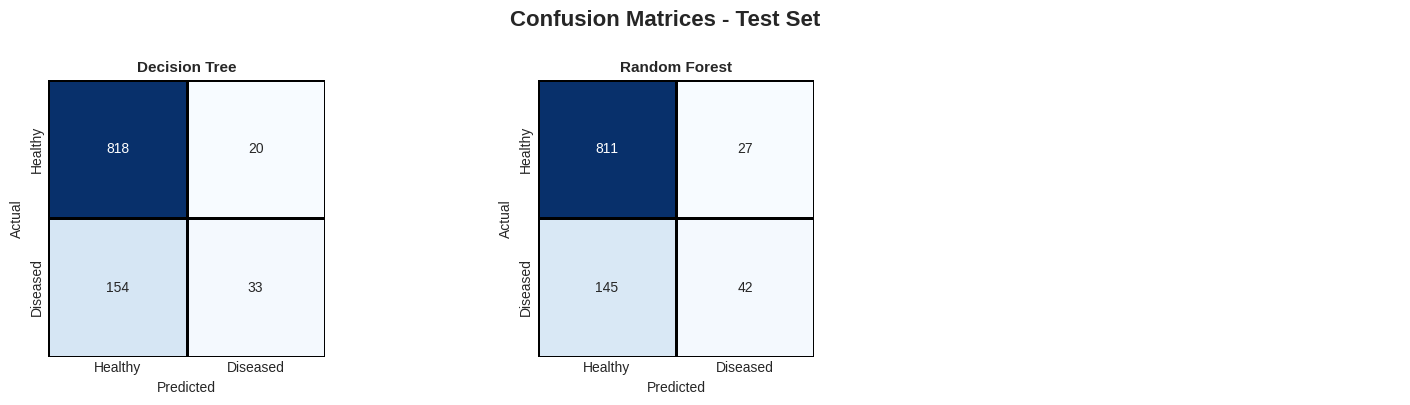

In [43]:
# Plot confusion matrices for all models
n_models = len(trained_models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.ravel()

for idx, (name, model) in enumerate(trained_models.items()):
    y_test_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_test_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=False, square=True, linewidths=2, linecolor='black')
    axes[idx].set_title(f'{name}', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].set_xticklabels(['Healthy', 'Diseased'])
    axes[idx].set_yticklabels(['Healthy', 'Diseased'])

# Hide extra subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices - Test Set', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

### 5.7 ROC Curves

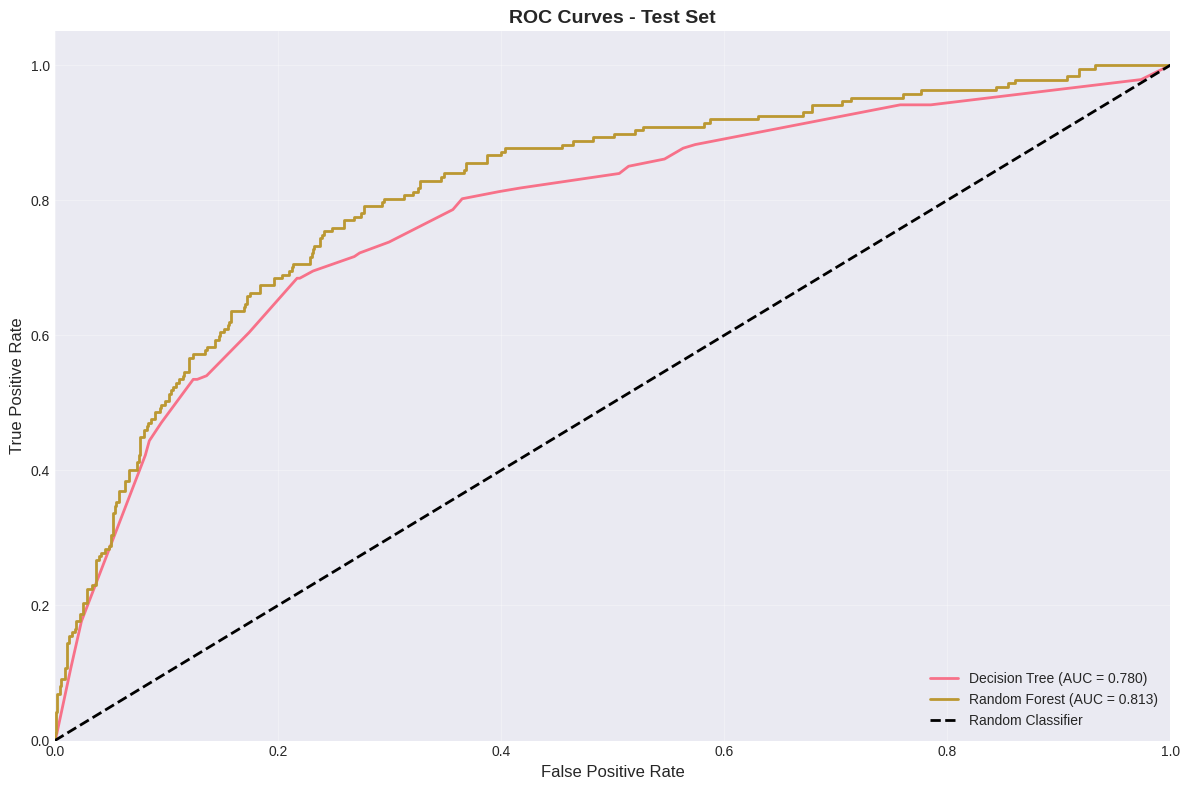

In [44]:
from sklearn.metrics import roc_curve, auc

# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for name, model in trained_models.items():
    if hasattr(model, 'predict_proba'):
        y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_test_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Test Set', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.8 Detailed Classification Reports

In [96]:
# Print classification reports for top 3 models
top_3_models = test_results_df.head(3)['Model'].tolist()

print(" DETAILED CLASSIFICATION REPORTS ")

for name in top_3_models:
    model = trained_models[name]
    y_test_pred = model.predict(X_test_scaled)

    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_test_pred,
                                target_names=['Healthy', 'Diseased'],
                                digits=3))

 DETAILED CLASSIFICATION REPORTS 

Model: Random Forest
              precision    recall  f1-score   support

     Healthy      0.848     0.968     0.904       838
    Diseased      0.609     0.225     0.328       187

    accuracy                          0.832      1025
   macro avg      0.729     0.596     0.616      1025
weighted avg      0.805     0.832     0.799      1025


Model: Decision Tree
              precision    recall  f1-score   support

     Healthy      0.842     0.976     0.904       838
    Diseased      0.623     0.176     0.275       187

    accuracy                          0.830      1025
   macro avg      0.732     0.576     0.589      1025
weighted avg      0.802     0.830     0.789      1025



## 6. Feature Importance Analysis

### 6.1 Identify Most Important Features

In [97]:
# Select best model based on test F1-score
best_model_name = test_results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f" FEATURE IMPORTANCE ANALYSIS ")
print(f"Using best model: {best_model_name}")
print(f"Test F1-Score: {test_results_df.iloc[0]['F1-Score']:.4f}\n")

 FEATURE IMPORTANCE ANALYSIS 
Using best model: Random Forest
Test F1-Score: 0.3281



In [47]:
# Extract feature importance
feature_names = X_train.columns.tolist()

if hasattr(best_model, 'feature_importances_'):
    # Tree-based models
    importances = best_model.feature_importances_
    importance_type = 'Feature Importance'

elif hasattr(best_model, 'coef_'):
    # Linear models
    importances = np.abs(best_model.coef_[0])
    importance_type = 'Absolute Coefficient'

else:
    # For models without built-in importance, use permutation importance
    from sklearn.inspection import permutation_importance
    print("Computing permutation importance (this may take a moment)...")
    result = permutation_importance(best_model, X_test_scaled, y_test,
                                   n_repeats=10, random_state=42, n_jobs=-1)
    importances = result.importances_mean
    importance_type = 'Permutation Importance'

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f"\n{importance_type} ({best_model_name}):")
print(feature_importance_df.to_string(index=False))


Feature Importance (Random Forest):
              Feature  Importance
           health_gen    0.206915
                  bmi    0.183597
              high_bp    0.164545
                  age    0.129811
         walking_diff    0.062654
            high_chol    0.060882
          health_phys    0.043939
       alcohol_misuse    0.031851
          health_ment    0.027380
history_heart_disease    0.022775
               gender    0.013526
               fruits    0.013212
      history_smoking    0.012672
      amount_activity    0.010376
           vegetables    0.008222
       history_stroke    0.006241
           chol_check    0.001404


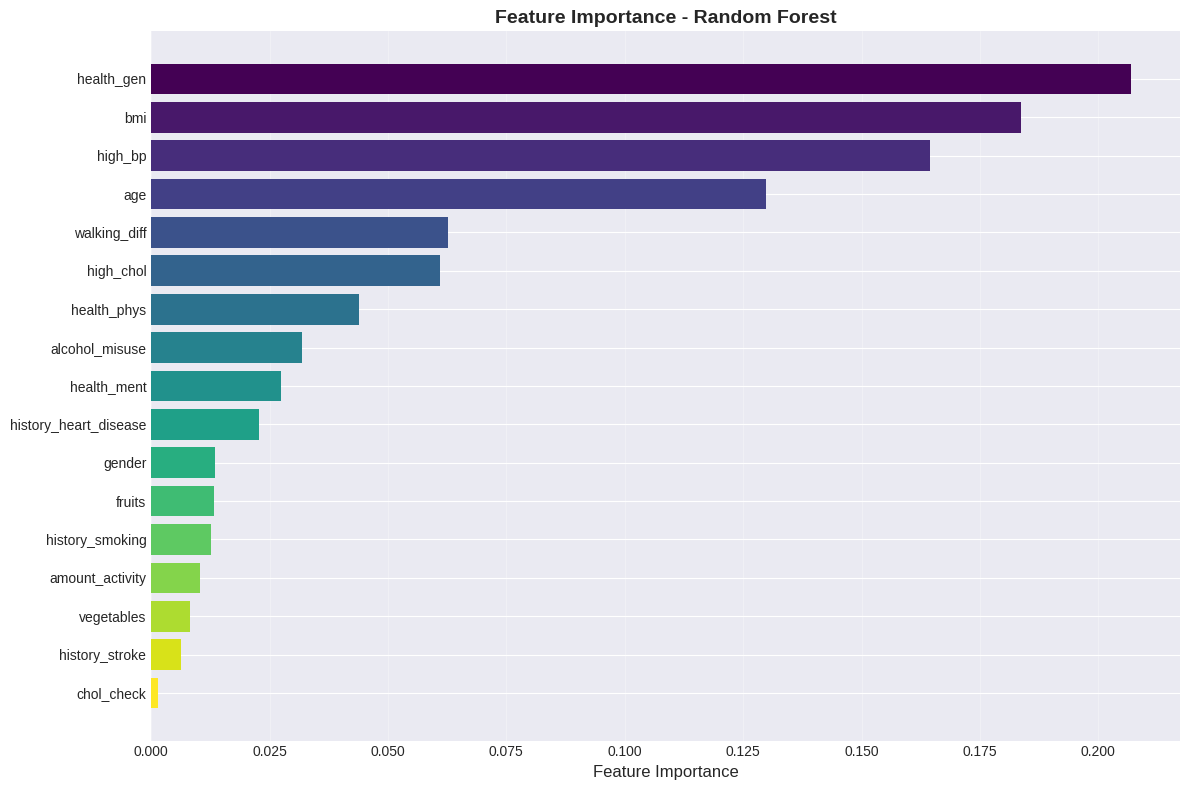


Most Important Feature: health_gen


In [48]:
# Visualize feature importance
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)
plt.xlabel(importance_type, fontsize=12)
plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Identify most important feature
most_important_feature = feature_importance_df.iloc[0]['Feature']
print(f"\nMost Important Feature: {most_important_feature}")

### 6.2 Retrain Without Best Feature

In [99]:
# Remove most important feature and retrain
print(f"\n RETRAINING WITHOUT '{most_important_feature}' ")

# Create datasets without best feature
X_train_reduced = X_train_scaled.drop(columns=[most_important_feature])
X_test_reduced = X_test_scaled.drop(columns=[most_important_feature])

print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"Reduced feature count: {X_train_reduced.shape[1]}")

# Train same model without best feature
from sklearn.base import clone
model_reduced = clone(best_model)
model_reduced.fit(X_train_reduced, y_train)

# Evaluate
y_test_pred_reduced = model_reduced.predict(X_test_reduced)

# Compare performance
comparison = pd.DataFrame({
    'Model': ['With All Features', f'Without {most_important_feature}'],
    'Accuracy': [
        accuracy_score(y_test, best_model.predict(X_test_scaled)),
        accuracy_score(y_test, y_test_pred_reduced)
    ],
    'Precision': [
        precision_score(y_test, best_model.predict(X_test_scaled)),
        precision_score(y_test, y_test_pred_reduced)
    ],
    'Recall': [
        recall_score(y_test, best_model.predict(X_test_scaled)),
        recall_score(y_test, y_test_pred_reduced)
    ],
    'F1-Score': [
        f1_score(y_test, best_model.predict(X_test_scaled)),
        f1_score(y_test, y_test_pred_reduced)
    ]
})

print("\nPerformance Comparison:")
print(comparison.to_string(index=False))

# Calculate impact
f1_drop = comparison.iloc[0]['F1-Score'] - comparison.iloc[1]['F1-Score']
f1_drop_pct = (f1_drop / comparison.iloc[0]['F1-Score']) * 100

print(f"\nF1-Score dropped by: {f1_drop:.4f} ({f1_drop_pct:.2f}%)")

if f1_drop_pct > 10:
    print(f" Significant drop! '{most_important_feature}' is crucial for prediction.")
elif f1_drop_pct > 5:
    print(f" Moderate drop. '{most_important_feature}' is important but not critical.")
else:
    print(f" Minimal impact. Model is robust without '{most_important_feature}'.")


 RETRAINING WITHOUT 'health_gen' 
Original feature count: 17
Reduced feature count: 16

Performance Comparison:
             Model  Accuracy  Precision   Recall  F1-Score
 With All Features  0.832195   0.608696 0.224599  0.328125
Without health_gen  0.833171   0.642857 0.192513  0.296296

F1-Score dropped by: 0.0318 (9.70%)
 Moderate drop. 'health_gen' is important but not critical.


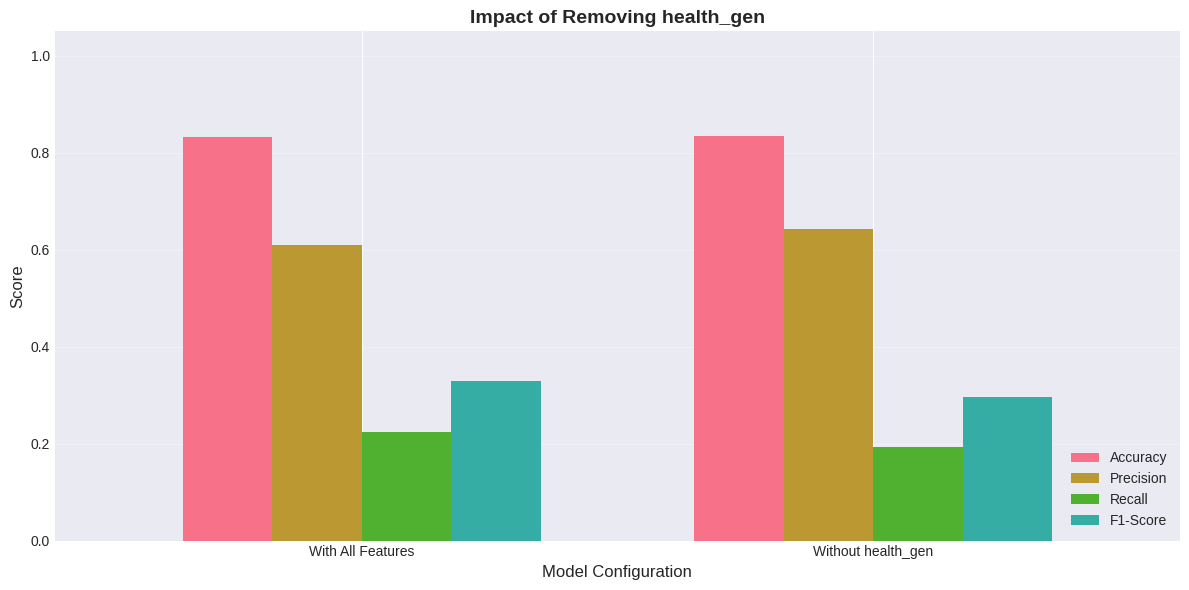

In [50]:
# Visualize comparison
comparison_plot = comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

comparison_plot.plot(kind='bar', figsize=(12, 6), width=0.7)
plt.xlabel('Model Configuration', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title(f'Impact of Removing {most_important_feature}', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.ylim([0, 1.05])
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Summary and Conclusions

In [101]:
print("=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)

print("\n1. DATASET:")
print(f"   - Total samples: {len(df)}")
print(f"   - Features: {X.shape[1]} ({len(numerical_features)} numerical, {len(categorical_features)} categorical)")
print(f"   - Disease prevalence: {(df[target].sum() / len(df)) * 100:.2f}%")

print("\n2. DATA QUALITY:")
if len(missing_data) > 0:
    print(f"   - Missing data: {missing_data['Missing_Percentage'].max():.2f}% (max per feature)")
else:
    print("   - No missing data detected")
print(f"   - Handled via: Median imputation (numerical), Mode imputation (categorical)")

print("\n3. UNSUPERVISED LEARNING:")
print(f"   - PCA: {n_components_95} components explain 95% variance")
print(f"   - K-Means: Optimal k = {optimal_k} (Silhouette = {silhouette_score(X_train_scaled, cluster_labels):.3f})")
print("   - Clusters show [evaluate based on your results] alignment with disease status")

print("\n4. BEST CLASSIFIER:")
best_result = test_results_df.iloc[0]
print(f"   - Model: {best_result['Model']}")
print(f"   - Test Accuracy: {best_result['Accuracy']:.4f}")
print(f"   - Test Precision: {best_result['Precision']:.4f}")
print(f"   - Test Recall: {best_result['Recall']:.4f}")
print(f"   - Test F1-Score: {best_result['F1-Score']:.4f}")
print(f"   - Test ROC-AUC: {best_result['ROC-AUC']:.4f}")

print("\n5. OVERFITTING:")
best_comparison = comparison_df[comparison_df['Model'] == best_model_name].iloc[0]
if best_comparison['Difference'] > 0.05:
    print(f"   -  Moderate overfitting detected (Train-Test gap: {best_comparison['Difference']:.4f})")
else:
    print(f"   -  Good generalization (Train-Test gap: {best_comparison['Difference']:.4f})")

print("\n6. FEATURE IMPORTANCE:")
print(f"   - Most important: {most_important_feature}")
print(f"   - Impact of removal: {f1_drop_pct:.2f}% F1-score drop")
print("   - Top 3 features:")
for i in range(min(3, len(feature_importance_df))):
    print(f"     {i+1}. {feature_importance_df.iloc[i]['Feature']}")

print("\n" + "=" * 80)

ANALYSIS SUMMARY

1. DATASET:
   - Total samples: 5124
   - Features: 17 (6 numerical, 11 categorical)
   - Disease prevalence: 18.27%

2. DATA QUALITY:
   - Missing data: 29.55% (max per feature)
   - Handled via: Median imputation (numerical), Mode imputation (categorical)

3. UNSUPERVISED LEARNING:
   - PCA: 16 components explain 95% variance
   - K-Means: Optimal k = 2 (Silhouette = 0.239)
   - Clusters show [evaluate based on your results] alignment with disease status

4. BEST CLASSIFIER:
   - Model: Random Forest
   - Test Accuracy: 0.8322
   - Test Precision: 0.6087
   - Test Recall: 0.2246
   - Test F1-Score: 0.3281
   - Test ROC-AUC: 0.8132

5. OVERFITTING:
   -  Moderate overfitting detected (Train-Test gap: 0.1264)

6. FEATURE IMPORTANCE:
   - Most important: health_gen
   - Impact of removal: 9.70% F1-score drop
   - Top 3 features:
     1. health_gen
     2. bmi
     3. high_bp



## 8. Save Results for Presentation

In [103]:
!mkdir -p '/content/results/'
# Save key results
results_dir = '/content/results/'

# Save performance comparison
test_results_df.to_csv(results_dir + 'model_performance.csv', index=False)
print(" Model performance saved")

# Save feature importance
feature_importance_df.to_csv(results_dir + 'feature_importance.csv', index=False)
print(" Feature importance saved")

# Save cross-validation results
cv_results_df.to_csv(results_dir + 'cross_validation_results.csv', index=False)
print(" Cross-validation results saved")

print("\nAll results saved to:", results_dir)

 Model performance saved
 Feature importance saved
 Cross-validation results saved

All results saved to: /content/results/
